[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_06/MFM_ch6_seminar/MFM_ch6_seminar.ipynb)

# MFM_ch6_seminar

Seminar 6 computations: Gaussian versus t tail dependence, Kendall tau and copula parameters, DCC for SPY and TLT with subsamples, Gaussian versus t copula with bootstrap likelihood ratio and intervals, Clayton versus Gumbel for joint losses of BET and Euro Stoxx 50, Forbes-Rigobon for 2008 and 2020, a residual-bootstrap band for the Bitcoin-S&P 500 DCC and the integration of BET with the Euro Stoxx 50 after 2020.

*Modelling Financial Markets (MFM), Chapter 6: Multivariate Volatility and Dependence. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_6'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/2026 MFM/MFM/Quantlets/Ch_06/MFM_ch6_seminar


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import networkx as nx
from scipy import stats, optimize, integrate
from scipy.signal import lfilter
from scipy.special import gammaln
try:
    from arch import arch_model
except ImportError:                      # Colab: pip install arch
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch'], check=True)
    from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [3]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
FAM_COL = {'gaussian': MainBlue, 't': IDAred, 'clayton': Forest, 'gumbel': Amber, 'frank': Purple}

SIDE = (5.6, 3.5)   # size of the charts placed next to text

SEED = 42
NUM = {}
TABLE_DIR = '.'


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def shade_crises(ax, alpha=0.12):
    for a, b in (('2008-09-15', '2009-03-31'), ('2020-02-20', '2020-04-30'), ('2022-01-03', '2022-10-31')):
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=Gray, alpha=alpha, lw=0)

## Data

In [4]:
import os
import numpy as np
import pandas as pd

REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# name -> (symbol, price field, label, start date)
ASSETS = {
    'spy':   ('SPY.US',        'adjusted_close', 'SPY (S&P 500 ETF)',          '2002-07-30'),
    'tlt':   ('TLT.US',        'adjusted_close', 'TLT (20+y Treasury ETF)',    '2002-07-30'),
    'ief':   ('IEF.US',        'adjusted_close', 'IEF (7-10y Treasury ETF)',   '2002-07-30'),
    'sp500': ('GSPC.INDX',     'close',          'S&P 500',                    '2000-01-01'),
    'stoxx': ('STOXX50E.INDX', 'close',          'Euro Stoxx 50',              '2000-01-01'),
    'bet':   ('BET',           'close',          'BET (Romania)',              '2000-01-01'),
    'bettr': ('BETTR.INDX',    'close',          'BET-TR (Romania)',           '2014-09-23'),
    'btc':   ('BTC-USD.CC',    'close',          'Bitcoin',                    '2014-09-17'),
    'vix':   ('VIX.INDX',      'close',          'VIX',                        '2000-01-01'),
    'jpm':   ('JPM.US',        'adjusted_close', 'JPMorgan Chase',             '2010-01-01'),
    'bac':   ('BAC.US',        'adjusted_close', 'Bank of America',            '2010-01-01'),
    'dbk':   ('DBK.XETRA',     'adjusted_close', 'Deutsche Bank',              '2010-01-01'),
    'bnp':   ('BNP.PA',        'adjusted_close', 'BNP Paribas',                '2010-01-01'),
    'tlv':   ('TLV.RO',        'adjusted_close', 'Banca Transilvania',         '2010-01-01'),
    'brd':   ('BRD.RO',        'adjusted_close', 'BRD-Groupe Societe Generale', '2010-01-01'),
}
# US-listed ETFs for the COVOL case study (Engle and Campos-Martins, 2023, Section 9)
COVOL_ETFS = ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY',
              'IWF', 'IWD', 'IWM', 'EFA', 'EEM', 'GLD', 'TLT', 'LQD', 'USO']
for _e in COVOL_ETFS:
    ASSETS['etf_' + _e.lower()] = (f'{_e}.US', 'adjusted_close', _e, '1999-12-31')
LABELS = {k: v[2] for k, v in ASSETS.items()}
SHORT = {'spy': 'SPY', 'tlt': 'TLT', 'ief': 'IEF', 'sp500': 'S&P 500', 'stoxx': 'Euro Stoxx 50', 'bet': 'BET',
         'bettr': 'BET-TR', 'btc': 'Bitcoin', 'vix': 'VIX', 'jpm': 'JPM', 'bac': 'BAC', 'dbk': 'DBK', 'bnp': 'BNP',
         'tlv': 'TLV', 'brd': 'BRD'}
BANKS = ['jpm', 'bac', 'dbk', 'bnp', 'tlv', 'brd']


def read_market(symbol):
    """Daily series of one asset from the course data."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def load_price(name, start=None, end=END):
    """Daily price, cleaned with the conventions of the chapter."""
    symbol, col, _, start0 = ASSETS[name]
    d = read_market(symbol).loc[start or start0:end]
    d = d[d[col] > 0].dropna(subset=[col])
    s = d[col]
    if name != 'btc':
        keep = s.index.dayofweek < 5                                   # no weekend quotes
        vol = d['volume'].fillna(0) if 'volume' in d else pd.Series(0.0, index=d.index)
        keep &= ~((s.diff() == 0) & (vol <= 0)).values                # holidays: unchanged price AND zero volume
        s = s[keep]                                                    # (trading days with volume and an unchanged price stay)
    return s.rename(name)


def joint_prices(names, start=None, end=END):
    """Prices of the assets on their common trading days."""
    return pd.concat([load_price(n, start, end) for n in names], axis=1, join='inner').dropna()


def joint_returns(names, start=None, end=END):
    """Daily log returns, computed AFTER aligning the prices on common days."""
    return np.log(joint_prices(names, start, end)).diff().dropna()


def weekly_returns(names, start=None, end=END):
    """Weekly log returns: the last common price of each week (Friday), then differences."""
    p = joint_prices(names, start, end)
    return np.log(p.resample('W-FRI').last()).diff().dropna()

## Dependence tools: EWMA, GARCH, DCC, Forbes-Rigobon, copulas

In [5]:
import numpy as np
import pandas as pd
from scipy import stats, optimize, integrate
from scipy.signal import lfilter
from scipy.special import gammaln
from arch import arch_model
try:
    from numba import njit
except ImportError:                      # without numba the same functions run as plain Python (slower)
    def njit(*args, **kwargs):
        return args[0] if (len(args) == 1 and callable(args[0])) else (lambda f: f)


# =============================================================================
# EWMA and rolling window
# =============================================================================
def ewma_cov(R, lam=0.94, init=100):
    """Sigma_t = lam*Sigma_{t-1} + (1-lam) r_{t-1} r_{t-1}'  (forecast for day t, without r_t).
    The first init observations only initialise the recursion: Sigma_init = their covariance; NaN before init."""
    X = np.asarray(R, dtype=float)
    T, N = X.shape
    S = np.full((T, N, N), np.nan)
    S[init] = np.cov(X[:init].T)
    for t in range(init + 1, T):
        S[t] = lam * S[t - 1] + (1 - lam) * np.outer(X[t - 1], X[t - 1])
    return S


def ewma_corr(R, lam=0.94, i=0, j=1):
    S = ewma_cov(R, lam)
    return pd.Series(S[:, i, j] / np.sqrt(S[:, i, i] * S[:, j, j]), index=R.index)


def rolling_corr(R, window, a=None, b=None):
    a, b = a or R.columns[0], b or R.columns[1]
    return R[a].rolling(window).corr(R[b])


def fisher_ci(rho, n, level=0.95):
    """Confidence interval for a correlation by the Fisher z transformation (i.i.d. data)."""
    z, se = np.arctanh(rho), 1 / np.sqrt(n - 3)
    q = stats.norm.ppf(0.5 + level / 2)
    return np.tanh(z - q * se), np.tanh(z + q * se)


# =============================================================================
# Univariate GARCH(1,1) -- the first step of DCC
# =============================================================================
def garch_filter(r, dist='normal'):
    """GARCH(1,1) with constant mean on returns in percent (QML).
    Returns the parameters, the conditional volatility (%) and the standardised residuals."""
    res = arch_model(100 * r, mean='Constant', vol='GARCH', p=1, q=1, dist=dist).fit(disp='off')
    z = (res.resid / res.conditional_volatility).rename(r.name)
    return res.params, res.conditional_volatility.rename(r.name), z, res.loglikelihood


def garch_all(R, dist='normal'):
    out = {c: garch_filter(R[c], dist) for c in R.columns}
    Z = pd.concat([out[c][2] for c in R.columns], axis=1)
    V = pd.concat([out[c][1] for c in R.columns], axis=1)
    P = pd.DataFrame({c: out[c][0] for c in R.columns})
    ll = sum(out[c][3] for c in R.columns)
    return P, V, Z, ll


# =============================================================================
# DCC (Engle, 2002): Q_t = (1-a-b) Qbar + a z_{t-1} z_{t-1}' + b Q_{t-1}
# =============================================================================
def dcc_path(Z, a, b, Qbar=None):
    """Correlation matrices R_t (T x N x N). Each element of Q_t follows a linear recursion,
    computed in vectorised form with lfilter."""
    X = np.asarray(Z, dtype=float)
    T, N = X.shape
    Qbar = np.cov(X.T, bias=True) if Qbar is None else Qbar
    P = np.einsum('ti,tj->tij', X, X)                  # z_t z_t'
    drive = np.empty_like(P)
    drive[0] = Qbar
    drive[1:] = (1 - a - b) * Qbar + a * P[:-1]         # input at time t: uses z_{t-1}
    Q = lfilter([1.0], [1.0, -b], drive.reshape(T, -1), axis=0).reshape(T, N, N)
    Q[0] = Qbar
    d = np.sqrt(np.einsum('tii->ti', Q))
    return Q / (d[:, :, None] * d[:, None, :])


@njit(cache=True)
def dcc2_corr_loglik(x, y, a, b, q11b, q22b, q12b):
    """Bivariate case of dcc_corr_loglik, written as a single loop (same recursion as dcc_path)."""
    q11, q22, q12 = q11b, q22b, q12b
    c = 1.0 - a - b
    ll = 0.0
    for t in range(len(x)):
        r = q12 / np.sqrt(q11 * q22)
        d = 1.0 - r * r
        ll += -0.5 * (np.log(d) + (x[t] * x[t] + y[t] * y[t] - 2.0 * r * x[t] * y[t]) / d - x[t] * x[t] - y[t] * y[t])
        q11 = c * q11b + a * x[t] * x[t] + b * q11
        q22 = c * q22b + a * y[t] * y[t] + b * q22
        q12 = c * q12b + a * x[t] * y[t] + b * q12
    return ll


def dcc_corr_loglik(Z, a, b, Qbar=None):
    """Correlation part of the log-likelihood: -1/2 sum(log|R_t| + z'R_t^{-1}z - z'z)."""
    X = np.asarray(Z, dtype=float)
    if X.shape[1] == 2:
        Q = np.cov(X.T, bias=True) if Qbar is None else Qbar
        return dcc2_corr_loglik(np.ascontiguousarray(X[:, 0]), np.ascontiguousarray(X[:, 1]), float(a), float(b),
                                Q[0, 0], Q[1, 1], Q[0, 1])
    R = dcc_path(X, a, b, Qbar)
    sign, logdet = np.linalg.slogdet(R)
    quad = np.einsum('ti,tij,tj->t', X, np.linalg.inv(R), X)
    return -0.5 * np.sum(logdet + quad - np.sum(X ** 2, axis=1))


def ccc_loglik(Z):
    """CCC (Bollerslev, 1990): constant correlation = DCC with a = b = 0."""
    return dcc_corr_loglik(Z, 0.0, 0.0)


def _num_hessian(f, x, h=1e-4):
    k = len(x)
    H = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            e_i, e_j = np.eye(k)[i] * h, np.eye(k)[j] * h
            H[i, j] = (f(x + e_i + e_j) - f(x + e_i - e_j) - f(x - e_i + e_j) + f(x - e_i - e_j)) / (4 * h * h)
    return H


def dcc_fit(Z, start=(0.03, 0.95)):
    """Step 2 of DCC: (a, b) by maximum likelihood, with Qbar fixed at the sample correlation
    (correlation targeting). The standard errors come from the step-2 Hessian (they ignore the step-1 error)."""
    X = np.asarray(Z, dtype=float)
    Qbar = np.cov(X.T, bias=True)

    def nll(p):
        a, b = p
        if a < 0 or b < 0 or a + b >= 0.9999:
            return 1e10
        return -dcc_corr_loglik(X, a, b, Qbar)

    best = None
    for s in (start, (0.01, 0.98), (0.05, 0.90), (0.10, 0.80)):
        r = optimize.minimize(nll, s, method='Nelder-Mead', options=dict(xatol=1e-7, fatol=1e-7, maxiter=4000))
        if best is None or r.fun < best.fun:
            best = r
    a, b = best.x
    try:
        H = _num_hessian(lambda p: -nll(p), best.x)
        se = np.sqrt(np.diag(np.linalg.inv(-H)))
    except Exception:
        se = np.array([np.nan, np.nan])
    return dict(a=a, b=b, se_a=se[0], se_b=se[1], loglik=-best.fun, Qbar=Qbar,
                R=dcc_path(X, a, b, Qbar), ccc_loglik=ccc_loglik(X))


# =============================================================================
# Forbes-Rigobon (2002)
# =============================================================================
def fr_adjust(rho_c, delta):
    """Crisis correlation adjusted for the rise in the variance of the source market:
    rho* = rho_c / sqrt(1 + delta (1 - rho_c^2)), delta = Var_crisis/Var_calm - 1."""
    return rho_c / np.sqrt(1 + delta * (1 - rho_c ** 2))


def fr_inflation(rho, delta):
    """Correlation measured in the crisis when the true correlation does not change: rho sqrt((1+delta)/(1+delta rho^2))."""
    return rho * np.sqrt((1 + delta) / (1 + delta * rho ** 2))


def fisher_z_test(rho1, n1, rho0, n0):
    """H0: rho1 <= rho0 (one-sided test, independent samples)."""
    z = (np.arctanh(rho1) - np.arctanh(rho0)) / np.sqrt(1 / (n1 - 3) + 1 / (n0 - 3))
    return z, 1 - stats.norm.cdf(z)


def crisis_table(ret2, source, targets, calm, crisis):
    """Calm vs crisis correlation, the Forbes-Rigobon adjustment and the Fisher z test for several markets."""
    rows = []
    c0, c1 = ret2.loc[calm[0]:calm[1]], ret2.loc[crisis[0]:crisis[1]]
    delta = c1[source].var() / c0[source].var() - 1
    for tg in targets:
        r0, r1 = c0[source].corr(c0[tg]), c1[source].corr(c1[tg])
        adj = fr_adjust(r1, delta)
        n0, n1 = len(c0) // 2, len(c1) // 2          # overlapping 2-day returns: effective n ~ n/2
        rows.append(dict(target=tg, rho_calm=r0, rho_crisis=r1, delta=delta, rho_adj=adj,
                         z_raw=fisher_z_test(r1, n1, r0, n0)[0], p_raw=fisher_z_test(r1, n1, r0, n0)[1],
                         z_adj=fisher_z_test(adj, n1, r0, n0)[0], p_adj=fisher_z_test(adj, n1, r0, n0)[1],
                         n_calm=len(c0), n_crisis=len(c1)))
    return pd.DataFrame(rows).set_index('target')


def exceedance_corr(x, y, qs):
    """Exceedance correlation (Longin-Solnik, 2001): corr(x, y | x<q_x, y<q_y) for lower tails and
    corr(x, y | x>q_x, y>q_y) for upper tails, at the same marginal quantiles."""
    out = []
    for q in qs:
        lo = (x <= np.quantile(x, q)) & (y <= np.quantile(y, q))
        hi = (x >= np.quantile(x, 1 - q)) & (y >= np.quantile(y, 1 - q))
        out.append((q, np.corrcoef(x[lo], y[lo])[0, 1] if lo.sum() > 5 else np.nan, lo.sum(),
                    np.corrcoef(x[hi], y[hi])[0, 1] if hi.sum() > 5 else np.nan, hi.sum()))
    return pd.DataFrame(out, columns=['q', 'rho_low', 'n_low', 'rho_high', 'n_high']).set_index('q')


# =============================================================================
# Bivariate copulas
# =============================================================================
FAMILIES = ['gaussian', 't', 'clayton', 'gumbel', 'frank']
FAM_LABEL = {'gaussian': 'Gaussian', 't': 'Student t', 'clayton': 'Clayton', 'gumbel': 'Gumbel', 'frank': 'Frank'}
EPS = 1e-10


def pseudo_obs(X):
    """Pseudo-observations: rank / (n + 1), column by column."""
    X = np.asarray(X, dtype=float)
    return np.column_stack([stats.rankdata(X[:, k]) / (len(X) + 1) for k in range(X.shape[1])])


def kendall_tau(u, v):
    return stats.kendalltau(u, v)[0]


def spearman_rho(u, v):
    return stats.spearmanr(u, v)[0]


def _debye1(x):
    if abs(x) < 1e-8:
        return 1.0
    val = integrate.quad(lambda t: t / np.expm1(t), 0, abs(x))[0] / abs(x)
    return val if x > 0 else val + abs(x) / 2


def tau_of(fam, theta):
    """Kendall's tau implied by the copula parameter."""
    if fam in ('gaussian', 't'):
        return 2 / np.pi * np.arcsin(theta[0] if np.ndim(theta) else theta)
    th = float(np.atleast_1d(theta)[0])
    if fam == 'clayton':
        return th / (th + 2)
    if fam == 'gumbel':
        return 1 - 1 / th
    if fam == 'frank':
        return 1 - 4 / th * (1 - _debye1(th))


def theta_from_tau(fam, tau):
    """Inversion of the tau <-> parameter relation (method of moments on Kendall's tau)."""
    if fam in ('gaussian', 't'):
        return np.sin(np.pi * tau / 2)
    if fam == 'clayton':
        return 2 * tau / (1 - tau)
    if fam == 'gumbel':
        return 1 / (1 - tau)
    if fam == 'frank':
        return optimize.brentq(lambda th: tau_of('frank', th) - tau, 1e-6 if tau > 0 else -60, 60 if tau > 0 else -1e-6)


def tail_dep(fam, par):
    """(lambda_L, lambda_U) for the given parameters."""
    if fam == 'gaussian':
        return 0.0, 0.0
    if fam == 't':
        rho, nu = par
        lam = 2 * stats.t.cdf(-np.sqrt((nu + 1) * (1 - rho) / (1 + rho)), nu + 1)
        return lam, lam
    th = par[0]
    if fam == 'clayton':
        return 2 ** (-1 / th), 0.0
    if fam == 'gumbel':
        return 0.0, 2 - 2 ** (1 / th)
    return 0.0, 0.0


def log_density(fam, par, u, v):
    u = np.clip(u, EPS, 1 - EPS)
    v = np.clip(v, EPS, 1 - EPS)
    if fam == 'gaussian':
        rho = par[0]
        x, y = stats.norm.ppf(u), stats.norm.ppf(v)
        return -0.5 * np.log(1 - rho ** 2) - (rho ** 2 * (x ** 2 + y ** 2) - 2 * rho * x * y) / (2 * (1 - rho ** 2))
    if fam == 't':
        rho, nu = par
        x, y = stats.t.ppf(u, nu), stats.t.ppf(v, nu)
        return (gammaln((nu + 2) / 2) + gammaln(nu / 2) - 2 * gammaln((nu + 1) / 2) - 0.5 * np.log(1 - rho ** 2)
                - (nu + 2) / 2 * np.log1p((x ** 2 + y ** 2 - 2 * rho * x * y) / (nu * (1 - rho ** 2)))
                + (nu + 1) / 2 * (np.log1p(x ** 2 / nu) + np.log1p(y ** 2 / nu)))
    th = par[0]
    if fam == 'clayton':
        return (np.log1p(th) - (1 + th) * (np.log(u) + np.log(v))
                - (2 + 1 / th) * np.log(u ** -th + v ** -th - 1))
    if fam == 'gumbel':
        lu, lv = -np.log(u), -np.log(v)
        A = lu ** th + lv ** th
        Ath = A ** (1 / th)
        return (-Ath - np.log(u) - np.log(v) + (th - 1) * (np.log(lu) + np.log(lv))
                + (2 / th - 2) * np.log(A) + np.log1p((th - 1) / Ath))
    if fam == 'frank':
        e = -np.expm1(-th)
        den = e - (-np.expm1(-th * u)) * (-np.expm1(-th * v))
        return np.log(th * e) - th * (u + v) - 2 * np.log(np.abs(den))


def h_func(fam, par, u, v):
    """h(v|u) = dC(u,v)/du: the conditional distribution function (Rosenblatt transform)."""
    u = np.clip(u, EPS, 1 - EPS)
    v = np.clip(v, EPS, 1 - EPS)
    if fam == 'gaussian':
        rho = par[0]
        x, y = stats.norm.ppf(u), stats.norm.ppf(v)
        return stats.norm.cdf((y - rho * x) / np.sqrt(1 - rho ** 2))
    if fam == 't':
        rho, nu = par
        x, y = stats.t.ppf(u, nu), stats.t.ppf(v, nu)
        return stats.t.cdf((y - rho * x) / np.sqrt((nu + x ** 2) * (1 - rho ** 2) / (nu + 1)), nu + 1)
    th = par[0]
    if fam == 'clayton':
        return u ** (-th - 1) * (u ** -th + v ** -th - 1) ** (-1 / th - 1)
    if fam == 'gumbel':
        lu, lv = -np.log(u), -np.log(v)
        A = lu ** th + lv ** th
        return np.exp(-A ** (1 / th)) / u * lu ** (th - 1) * A ** (1 / th - 1)
    if fam == 'frank':
        a, b = np.expm1(-th * u), np.expm1(-th * v)
        return (a + 1) * b / (np.expm1(-th) + a * b)


def simulate(fam, par, n, rng):
    """Simulation of n pairs (u, v) from the copula."""
    if fam == 'gaussian':
        rho = par[0]
        z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
        return stats.norm.cdf(z)
    if fam == 't':
        rho, nu = par
        z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
        w = np.sqrt(nu / rng.chisquare(nu, n))
        return stats.t.cdf(z * w[:, None], nu)
    th = par[0]
    if fam == 'clayton':          # Marshall-Olkin with a Gamma(1/theta) frailty
        V = rng.gamma(1 / th, 1, n)
        E = rng.exponential(1, (n, 2))
        return (1 + E / V[:, None]) ** (-1 / th)
    if fam == 'gumbel':           # Marshall-Olkin with a positive stable frailty, alpha = 1/theta (Kanter)
        al = 1 / th
        U = rng.uniform(0, np.pi, n)
        W = rng.exponential(1, n)
        S = np.sin(al * U) / np.sin(U) ** (1 / al) * (np.sin((1 - al) * U) / W) ** ((1 - al) / al)
        E = rng.exponential(1, (n, 2))
        return np.exp(-(E / S[:, None]) ** al)
    if fam == 'frank':            # inverting the h function
        u, w = rng.uniform(size=n), rng.uniform(size=n)
        v = -np.log1p(w * np.expm1(-th) / (w + (1 - w) * np.exp(-th * u))) / th
        return np.column_stack([u, v])


def fit_copula(fam, u, v):
    """ML estimation on pseudo-observations (canonical maximum likelihood, CML)."""
    tau = kendall_tau(u, v)
    if fam == 'gaussian':
        f = lambda p: -np.sum(log_density('gaussian', [np.tanh(p[0])], u, v))
        r = optimize.minimize(f, [np.arctanh(np.sin(np.pi * tau / 2))], method='BFGS')
        par = [np.tanh(r.x[0])]
    elif fam == 't':
        f = lambda p: -np.sum(log_density('t', [np.tanh(p[0]), 2.01 + np.exp(p[1])], u, v))
        best = None
        for nu0 in (3, 6, 15):
            r = optimize.minimize(f, [np.arctanh(np.sin(np.pi * tau / 2)), np.log(nu0 - 2.01)], method='Nelder-Mead',
                                  options=dict(xatol=1e-6, fatol=1e-6))
            if best is None or r.fun < best.fun:
                best = r
        r = best
        par = [np.tanh(r.x[0]), 2.01 + np.exp(r.x[1])]
    else:
        lo, hi = {'clayton': (1e-4, 30), 'gumbel': (1.0001, 30), 'frank': (1e-4, 60)}[fam]
        f = lambda p: -np.sum(log_density(fam, [p], u, v))
        th0 = min(max(theta_from_tau(fam, max(tau, 0.02)), lo * 1.01), hi * 0.99)
        r = optimize.minimize_scalar(f, bounds=(lo, hi), method='bounded', options=dict(xatol=1e-7))
        if f(th0) < r.fun:
            r = optimize.minimize_scalar(f, bracket=(lo * 1.01, th0, hi * 0.99), bounds=(lo, hi), method='bounded')
        par = [r.x]
    ll = np.sum(log_density(fam, par, u, v))
    k = 2 if fam == 't' else 1
    lamL, lamU = tail_dep(fam, par)
    return dict(family=fam, par=list(map(float, par)), loglik=float(ll), aic=float(2 * k - 2 * ll),
                bic=float(k * np.log(len(u)) - 2 * ll), tau_model=float(tau_of(fam, par if fam in ('gaussian', 't') else par[0])),
                lamL=float(lamL), lamU=float(lamU))


def cvm_rosenblatt(fam, par, u, v, chunk=1500):
    """S_n^(B) (Genest, Remillard & Beaudoin, 2009): Cramer-von Mises distance between the empirical
    distribution of the Rosenblatt pairs (u, h(v|u)) and the independence copula."""
    E = np.column_stack([u, h_func(fam, par, u, v)])
    n = len(E)
    t1 = n / 9
    t2 = np.sum((1 - E[:, 0] ** 2) * (1 - E[:, 1] ** 2)) / 2
    t3 = 0.0
    for i in range(0, n, chunk):
        Ei = E[i:i + chunk]
        t3 += np.sum((1 - np.maximum(Ei[:, None, 0], E[None, :, 0])) * (1 - np.maximum(Ei[:, None, 1], E[None, :, 1])))
    return t1 - t2 + t3 / n


def gof_test(fam, u, v, B=200, seed=42, fit=None):
    """Goodness-of-fit test with a parametric bootstrap: simulate from the fitted copula, pseudo-observations,
    refit, statistic S_n^(B); p-value = share of bootstrap statistics >= the observed one."""
    fit = fit or fit_copula(fam, u, v)
    s0 = cvm_rosenblatt(fam, fit['par'], u, v)
    rng = np.random.default_rng(seed)
    sb = []
    for _ in range(B):
        X = simulate(fam, fit['par'], len(u), rng)
        U = pseudo_obs(X)
        fb = fit_copula(fam, U[:, 0], U[:, 1])
        sb.append(cvm_rosenblatt(fam, fb['par'], U[:, 0], U[:, 1]))
    sb = np.array(sb)
    return dict(stat=float(s0), p=float((1 + np.sum(sb >= s0)) / (B + 1)), B=B)


def empirical_tail_dep(u, v, q):
    """lambda_L(q) = P(U<=q, V<=q)/q and lambda_U(q) = P(U>1-q, V>1-q)/q."""
    return np.mean((u <= q) & (v <= q)) / q, np.mean((u > 1 - q) & (v > 1 - q)) / q

## Helper functions

In [6]:
CALM08, CRISIS08 = ('2007-09-14', '2008-09-12'), ('2008-09-15', '2009-03-31')
CALM20, CRISIS20 = ('2019-02-19', '2020-02-19'), ('2020-02-20', '2020-04-30')

def two_day_returns(names, start='2006-01-01', end='2021-12-31'):
    """2-day returns (moving sum, as in Forbes-Rigobon): log p_t - log p_{t-2}, from common prices."""
    lp = np.log(joint_prices(names, start=start, end=end))
    return (lp - lp.shift(2)).dropna()


def simulate_garch(mu, omega, alpha, beta, eps):
    """Returns (in %) from a GARCH(1,1) with constant mean and the standardised innovations eps."""
    T = len(eps)
    r = np.empty(T)
    s2 = omega / (1 - alpha - beta)
    for t in range(T):
        r[t] = mu + np.sqrt(s2) * eps[t]
        s2 = omega + alpha * (r[t] - mu) ** 2 + beta * s2
    return r


def t_score_rho(rho, nu, x, y):
    """d log c_t / d rho for the t copula (x, y = the t_nu quantiles of the pseudo-observations)."""
    Q = x * x + y * y - 2 * rho * x * y
    D = nu * (1 - rho ** 2)
    dQD = (-2 * x * y * (1 - rho ** 2) + 2 * rho * Q) / (nu * (1 - rho ** 2) ** 2)
    return rho / (1 - rho ** 2) - (nu + 2) / 2 * dQD / (1 + Q / D)


@njit(cache=True)
def gas_t_nll(om, A, Bp, nu, x, y, cst):
    """Minus the log-likelihood of the GAS t copula (same recursion as gas_filter); x, y = the t_nu quantiles."""
    f = om / (1.0 - Bp)
    ll = 0.0
    for t in range(len(x)):
        r = np.tanh(f)
        if abs(r) >= 0.9999:
            return 1e10
        Q = x[t] * x[t] + y[t] * y[t] - 2.0 * r * x[t] * y[t]
        D = nu * (1.0 - r * r)
        ll += (cst - 0.5 * np.log(1.0 - r * r) - (nu + 2.0) / 2.0 * np.log1p(Q / D)
               + (nu + 1.0) / 2.0 * (np.log1p(x[t] * x[t] / nu) + np.log1p(y[t] * y[t] / nu)))
        dQD = (-2.0 * x[t] * y[t] * (1.0 - r * r) + 2.0 * r * Q) / (nu * (1.0 - r * r) ** 2)
        s = (r / (1.0 - r * r) - (nu + 2.0) / 2.0 * dQD / (1.0 + Q / D)) * (1.0 - r * r)
        f = om + A * s + Bp * f
    return -ll


def gas_filter(theta, u, v):
    om, A, Bp, nu = theta
    x, y = stats.t.ppf(u, nu), stats.t.ppf(v, nu)
    T = len(u)
    f = np.empty(T)
    f[0] = om / (1 - Bp)
    for t in range(T - 1):
        r = np.tanh(f[t])
        s = t_score_rho(r, nu, x[t], y[t]) * (1 - r * r)
        f[t + 1] = om + A * s + Bp * f[t]
    return np.tanh(f)


def gas_t_copula(u, v):
    fs = fit_copula('t', u, v)
    r0, nu0 = fs['par']

    uc, vc = np.clip(u, 1e-10, 1 - 1e-10), np.clip(v, 1e-10, 1 - 1e-10)

    def nll(p):
        om, A, Bp, lnu = p
        nu = 2.01 + np.exp(lnu)
        if not (0 <= Bp < 0.9995) or A < 0 or A > 1:
            return 1e10
        cst = gammaln((nu + 2) / 2) + gammaln(nu / 2) - 2 * gammaln((nu + 1) / 2)
        return gas_t_nll(om, A, Bp, nu, stats.t.ppf(uc, nu), stats.t.ppf(vc, nu), cst)
    best = None
    for Bp, A in ((0.98, 0.03), (0.95, 0.05), (0.99, 0.01)):
        p0 = [(1 - Bp) * np.arctanh(r0), A, Bp, np.log(nu0 - 2.01)]
        r = optimize.minimize(nll, p0, method='Nelder-Mead', options=dict(xatol=1e-6, fatol=1e-6, maxiter=4000))
        if best is None or r.fun < best.fun:
            best = r
    om, A, Bp, lnu = best.x
    nu = 2.01 + np.exp(lnu)
    rho = gas_filter((om, A, Bp, nu), u, v)
    return dict(om=om, A=A, B=Bp, nu=nu, rho=rho, ll=-best.fun, ll_static=fs['loglik'], rho_static=r0, nu_static=nu0,
                lr=2 * (-best.fun - fs['loglik']))


def bank_copula_data():
    R = joint_returns(['jpm', 'bac'])
    P, V, Z, ll = garch_all(R)
    U = pseudo_obs(Z.values)
    return R, Z, U

## Analysis

In [7]:
def joint_tail_prob(q, rho, nu=None):
    """P(U <= q, V <= q) for the Gaussian copula (nu=None) or the t copula (nu degrees of freedom), by deterministic
    one-dimensional quadrature: Y | X = x is Normal(rho x, 1 - rho^2), or
    t_{nu+1}(rho x, (nu + x^2)(1 - rho^2)/(nu + 1))."""
    if nu is None:
        a = stats.norm.ppf(q)
        f = lambda x: stats.norm.pdf(x) * stats.norm.cdf((a - rho * x) / np.sqrt(1 - rho ** 2))
    else:
        a = stats.t.ppf(q, nu)
        f = lambda x: stats.t.pdf(x, nu) * stats.t.cdf((a - rho * x) / np.sqrt((nu + x * x) * (1 - rho ** 2) / (nu + 1)), nu + 1)
    return integrate.quad(f, -np.inf, a, epsabs=1e-14, epsrel=1e-10, limit=200)[0]


def a_tail_gauss_t(rho=0.5, nus=(3, 4, 10, 30)):
    """A1: lambda of the t copula and the conditional probability P(V<=q | U<=q) at a finite level."""
    out = {}
    for nu in nus:
        arg = np.sqrt((nu + 1) * (1 - rho) / (1 + rho))
        out[nu] = dict(arg=arg, lam=2 * stats.t.cdf(-arg, nu + 1))
    qs = np.array([0.10, 0.05, 0.01, 0.001])
    gauss = np.array([joint_tail_prob(q, rho) / q for q in qs])
    t4 = np.array([joint_tail_prob(q, rho, 4) / q for q in qs])
    return out, qs, gauss, t4


def fig_tail_gauss_t(rho=0.5):
    qs = np.geomspace(0.001, 0.2, 30)
    g = [joint_tail_prob(q, rho) / q for q in qs]
    fig, ax = plt.subplots(figsize=(5.6, 3.5))
    ax.plot(qs, g, color=MainBlue, lw=1.6, label='Gaussian copula (rho = 0.5)')
    for nu, c in ((4, IDAred), (10, Amber)):
        ax.plot(qs, [joint_tail_prob(q, rho, nu) / q for q in qs], color=c, lw=1.6, label=f't copula (rho = 0.5, nu = {nu})')
        lam = 2 * stats.t.cdf(-np.sqrt((nu + 1) * (1 - rho) / (1 + rho)), nu + 1)
        ax.axhline(lam, color=c, ls=':', lw=0.9)
    ax.set_xscale('log')
    ax.set_xticks([0.01, 0.02, 0.05, 0.1, 0.2])
    ax.set_xticklabels(['1%', '2%', '5%', '10%', '20%'])
    ax.set_xlabel('q (log scale)')
    ax.set_ylabel('P(V <= q | U <= q)')
    ax.set_ylim(0, 0.8)
    legend_outside_bottom(ax, ncol=2, y=-0.18)
    save_fig('ch6_sem_tail_gauss_t')


def a_tau_to_theta():
    """A2: Kendall's tau for S&P 500 / Euro Stoxx 50 (weekly returns) and the implied parameters."""
    W = weekly_returns(['sp500', 'stoxx'], start='2000-01-01')
    U = pseudo_obs(W.values)
    tau = kendall_tau(U[:, 0], U[:, 1])
    out = dict(tau=tau, n=len(W), rhoS=spearman_rho(U[:, 0], U[:, 1]), pearson=W.corr().iloc[0, 1])
    for fam in ('gaussian', 'clayton', 'gumbel', 'frank'):
        th = theta_from_tau(fam, tau)
        out[fam] = th
        out[fam + '_lam'] = tail_dep(fam, [th])
    out['gauss_rhoS'] = 6 / np.pi * np.arcsin(out['gaussian'] / 2)
    return out, W, U


def a_forbes_rigobon_example(rho_calm=0.40, rho_crisis=0.60, var_ratio=4.0):
    delta = var_ratio - 1
    return dict(delta=delta, adj=fr_adjust(rho_crisis, delta), infl=rho_calm * np.sqrt((1 + delta) / (1 + delta * rho_calm ** 2)))


def b_dcc_spy_tlt():
    """B1: DCC on the full sample and on two subperiods; LR against CCC; the change in the mean correlation of z."""
    R = joint_returns(['spy', 'tlt'])
    P, V, Z, ll = garch_all(R)
    full = dcc_fit(Z)
    sub = {}
    for lab, sl in (('pre', slice(None, '2019-12-31')), ('post', slice('2020-01-01', None))):
        Rs = R.loc[sl]
        Ps, Vs, Zs, _ = garch_all(Rs)
        sub[lab] = dcc_fit(Zs)
        sub[lab]['n'] = len(Zs)
    z0, z1 = Z.loc[:'2021-12-31'], Z.loc['2022-01-01':]
    r0, r1 = z0.corr().iloc[0, 1], z1.corr().iloc[0, 1]
    zt, _ = fisher_z_test(r1, len(z1), r0, len(z0))
    return dict(full=full, sub=sub, r0=r0, r1=r1, zt=zt, p2=2 * (1 - stats.norm.cdf(abs(zt))),
                lr=2 * (full['loglik'] - full['ccc_loglik']), n=len(Z), P=P)


def b_gauss_vs_t(W, U, B=200, B_test=499):
    """B2: Gaussian vs t for S&P 500 / Euro Stoxx 50 weekly: ML, LR for nu, goodness of fit, bootstrap CI for lambda.
    The tests (goodness of fit and LR) use B_test = 499 replications, so the smallest possible p-value is 1/500 = 0.002."""
    u, v = U[:, 0], U[:, 1]
    fg, ft = fit_copula('gaussian', u, v), fit_copula('t', u, v)
    gg = gof_test('gaussian', u, v, B=B_test, seed=SEED, fit=fg)
    gt = gof_test('t', u, v, B=B_test, seed=SEED, fit=ft)
    lr = 2 * (ft['loglik'] - fg['loglik'])
    rng = np.random.default_rng(SEED)
    lam_b, nu_b = [], []
    for _ in range(B):
        X = pseudo_obs(simulate('t', ft['par'], len(u), rng))
        fb = fit_copula('t', X[:, 0], X[:, 1])
        lam_b.append(fb['lamL'])
        nu_b.append(fb['par'][1])
    lam_b, nu_b = np.array(lam_b), np.array(nu_b)
    # p-value of the LR by a parametric bootstrap under H0 (Gaussian copula), because nu = infinity is on the boundary
    lr_b = []
    for _ in range(B_test):
        X = pseudo_obs(simulate('gaussian', fg['par'], len(u), rng))
        lr_b.append(2 * (fit_copula('t', X[:, 0], X[:, 1])['loglik'] - fit_copula('gaussian', X[:, 0], X[:, 1])['loglik']))
    lr_b = np.array(lr_b)
    return dict(fg=fg, ft=ft, gg=gg, gt=gt, lr=lr, lr_p_boot=(1 + np.sum(lr_b >= lr)) / (len(lr_b) + 1),
                lr_p_chi2half=0.5 * (1 - stats.chi2.cdf(lr, 1)), lam_ci=np.percentile(lam_b, [5, 95]),
                nu_ci=np.percentile(nu_b, [5, 95]), emp=[empirical_tail_dep(u, v, q) for q in (0.05, 0.10)],
                lr_b=lr_b, lam_b=lam_b, nu_b=nu_b)


def b_losses_copula(B=200):
    """B3: daily BET / Euro Stoxx 50 losses (L = -r), GARCH-filtered: Clayton vs Gumbel (plus Gaussian and t)
    with a goodness-of-fit test. Gumbel on losses = dependence in the upper tail of the losses."""
    R = joint_returns(['bet', 'stoxx'], start='2010-01-01')
    P, V, Z, _ = garch_all(R)
    L = -Z
    U = pseudo_obs(L.values)
    u, v = U[:, 0], U[:, 1]
    res = {}
    for fam in ('clayton', 'gumbel', 'gaussian', 't'):
        f = fit_copula(fam, u, v)
        g = gof_test(fam, u, v, B=100 if fam == 't' else B, seed=SEED, fit=f)
        res[fam] = dict(fit=f, gof=g)
    emp = {q: empirical_tail_dep(u, v, q) for q in (0.05, 0.10)}
    return dict(res=res, tau=kendall_tau(u, v), n=len(U), start=str(R.index[0].date()), emp=emp, U=U)


def fig_losses_copula(U, res):
    u, v = U[:, 0], U[:, 1]
    fig, ax = plt.subplots(figsize=(4.2, 3.4))
    inner = ~((u > 0.9) & (v > 0.9)) & ~((u < 0.1) & (v < 0.1))
    ax.scatter(u[inner], v[inner], s=1.5, color=MainBlue, alpha=0.25, label='All days')
    m = (u > 0.9) & (v > 0.9)
    ax.scatter(u[m], v[m], s=3, color=IDAred, label='Joint large losses (both > 0.9)')
    m = (u < 0.1) & (v < 0.1)
    ax.scatter(u[m], v[m], s=3, color=Forest, label='Joint large gains (both < 0.1)')
    ax.set_xlabel('BET loss (uniform scale)')
    ax.set_ylabel('Euro Stoxx 50 loss (uniform scale)')
    legend_outside_bottom(ax, ncol=1, y=-0.18)
    save_fig('ch6_sem_losses_copula')


def b_forbes_rigobon():
    """B4: Forbes-Rigobon for 2008 and 2020, S&P 500 -> Euro Stoxx 50 and BET, plus the sensitivity to the window."""
    r2 = two_day_returns(['sp500', 'stoxx', 'bet'])
    t08 = crisis_table(r2, 'sp500', ['stoxx', 'bet'], CALM08, CRISIS08)
    t20 = crisis_table(r2, 'sp500', ['stoxx', 'bet'], CALM20, CRISIS20)
    t20b = crisis_table(r2, 'sp500', ['stoxx', 'bet'], CALM20, ('2020-02-20', '2020-03-31'))
    t08b = crisis_table(r2, 'sp500', ['stoxx', 'bet'], CALM08, ('2008-09-15', '2008-12-31'))
    for t, n in ((t08, '2008'), (t20, '2020'), (t20b, '2020_short'), (t08b, '2008_short')):
        t.to_csv(os.path.join(TABLE_DIR, f'ch6_sem_fr_{n}.csv'), float_format='%.6g')
    return t08, t20, t20b, t08b


def fig_forbes_rigobon_sem(t08, t20, draws=None):
    """B4: calm, raw and adjusted correlations, with the 90% bootstrap intervals of rho* (top)
    and the difference D = rho* - rho_calm with its interval (bottom)."""
    labels, calm, raw, adj, lo, hi, D, Dlo, Dhi = [], [], [], [], [], [], [], [], []
    for yr, tag, t in (('2008', '08', t08), ('2020', '20', t20)):
        for k in t.index:
            labels.append(f'{SHORT[k]}\n{yr}')
            calm.append(t.loc[k, 'rho_calm'])
            raw.append(t.loc[k, 'rho_crisis'])
            adj.append(t.loc[k, 'rho_adj'])
            if draws is not None:
                dd = draws[(tag, k)]
                lo.append(np.percentile(dd[:, 1], 5))
                hi.append(np.percentile(dd[:, 1], 95))
                D.append(t.loc[k, 'rho_adj'] - t.loc[k, 'rho_calm'])
                Dlo.append(np.percentile(dd[:, 0], 5))
                Dhi.append(np.percentile(dd[:, 0], 95))
    x = np.arange(len(labels))
    if draws is None:
        fig, ax = plt.subplots(figsize=(6.8, 3.0))
        axes = [ax]
    else:
        fig, axes = plt.subplots(2, 1, figsize=(5.6, 5.2), gridspec_kw=dict(height_ratios=[1.3, 1]))
    ax = axes[0]
    ax.bar(x - 0.26, calm, 0.24, color=Forest, label='Calm year before')
    ax.bar(x, raw, 0.24, color=IDAred, label='Crisis, raw')
    ax.bar(x + 0.26, adj, 0.24, color=MainBlue, label='Crisis, Forbes-Rigobon adjusted')
    if draws is not None:
        ax.errorbar(x + 0.26, adj, yerr=[np.array(adj) - lo, np.array(hi) - adj], fmt='none', ecolor='black',
                    capsize=2.5, lw=0.9, label='90% bootstrap interval of the adjusted value')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_ylabel('Correlation with the S&P 500')
    if draws is not None:
        ax = axes[1]
        ax.errorbar(D, x, xerr=[np.array(D) - Dlo, np.array(Dhi) - D], fmt='o', color=Purple, capsize=3, ms=4,
                    label='D = adjusted - calm, 90% interval')
        ax.axvline(0, color='black', lw=0.8)
        ax.set_yticks(x)
        ax.set_yticklabels([l.replace('\n', ' ') for l in labels], fontsize=7.5)
        ax.invert_yaxis()
        ax.set_xlabel('D (contagion needs D > 0)')
    hs, ls_ = [], []
    for a_ in axes:
        h, l = a_.get_legend_handles_labels()
        hs += h
        ls_ += l
    fig.tight_layout()
    fig.legend(hs, ls_, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False)
    save_fig('ch6_sem_forbes_rigobon')
    return dict(D=D, Dlo=Dlo, Dhi=Dhi, lo=lo, hi=hi, labels=labels)


def stationary_bootstrap_idx(n, mean_block, rng):
    """Indices of a stationary bootstrap (Politis-Romano): blocks of geometric length."""
    idx = np.empty(n, dtype=int)
    idx[0] = rng.integers(n)
    for t in range(1, n):
        idx[t] = rng.integers(n) if rng.uniform() < 1 / mean_block else (idx[t - 1] + 1) % n
    return idx


def simulate_dcc2(a, b, Qbar, eta):
    """Simulate bivariate standardised residuals from a DCC(1,1) with decorrelated innovations eta (T x 2)."""
    T = len(eta)
    eps = np.empty_like(eta)
    q11, q22, q12 = Qbar[0, 0], Qbar[1, 1], Qbar[0, 1]
    c = 1 - a - b
    for t in range(T):
        r = q12 / np.sqrt(q11 * q22)
        eps[t, 0] = eta[t, 0]
        eps[t, 1] = r * eta[t, 0] + np.sqrt(1 - r * r) * eta[t, 1]
        q11 = c * Qbar[0, 0] + a * eps[t, 0] ** 2 + b * q11
        q22 = c * Qbar[1, 1] + a * eps[t, 1] ** 2 + b * q22
        q12 = c * Qbar[0, 1] + a * eps[t, 0] * eps[t, 1] + b * q12
    return eps


def b_btc_bands(B=200):
    """B5: DCC Bitcoin / S&P 500 with bootstrap bands for the uncertainty of the parameters (a, b).
    Parametric residual bootstrap: the decorrelated innovations eta_t = L_t^{-1} eps_t (L_t the Cholesky factor of R_t)
    are drawn with replacement, a DCC is simulated with the estimated parameters, (a, b) is re-estimated,
    and the path R_t is recomputed on the original data with the bootstrap parameters."""
    R = joint_returns(['btc', 'sp500'], start='2014-09-17')
    P, V, Z, _ = garch_all(R)
    d = dcc_fit(Z)
    X = Z.values
    Rt = d['R']
    L = np.linalg.cholesky(Rt)
    eta = np.linalg.solve(L, X[:, :, None])[:, :, 0]
    eta = (eta - eta.mean(0)) / eta.std(0)
    rng = np.random.default_rng(SEED)
    paths, ab = [], []
    for _ in range(B):
        eb = eta[rng.integers(0, len(eta), len(eta))]
        Xb = simulate_dcc2(d['a'], d['b'], d['Qbar'], eb)
        db = dcc_fit(pd.DataFrame(Xb))
        Rb = dcc_path(X, db['a'], db['b'], d['Qbar'])       # the path on the original data with the bootstrap parameters
        paths.append(Rb[:, 0, 1])
        ab.append((db['a'], db['b']))
    paths, ab = np.array(paths), np.array(ab)
    rc = pd.Series(d['R'][:, 0, 1], index=Z.index)
    lo = pd.Series(np.percentile(paths, 5, axis=0), index=Z.index)
    hi = pd.Series(np.percentile(paths, 95, axis=0), index=Z.index)
    return dict(d=d, rc=rc, lo=lo, hi=hi, ab=ab, n=len(Z), start=str(Z.index[0].date()), paths=paths)


def fig_btc_bands(o):
    rc, lo, hi = o['rc'], o['lo'], o['hi']
    fig, ax = plt.subplots(figsize=(5.6, 3.5))
    ax.fill_between(rc.index, lo, hi, color=Amber, alpha=0.3, lw=0, label='90% residual-bootstrap band (uncertainty in a and b)')
    ax.plot(rc.index, rc, color=IDAred, lw=0.7, label='DCC(1,1) correlation Bitcoin / S&P 500')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('Conditional correlation')
    legend_outside_bottom(ax, ncol=1, y=-0.1)
    save_fig('ch6_sem_btc_bands')


def c_integration(B=2000, block=8):
    W = weekly_returns(['bet', 'stoxx'], start='2010-01-01')
    pre, post = W.loc[:'2019-12-31'], W.loc['2020-01-01':]
    r_pre, r_post = pre.corr().iloc[0, 1], post.corr().iloc[0, 1]
    # without the crisis weeks of March-April 2020
    post_x = post.drop(post.loc['2020-02-20':'2020-04-30'].index)
    r_post_x = post_x.corr().iloc[0, 1]
    rng = np.random.default_rng(SEED)
    diffs = []
    for _ in range(B):
        a = pre.values[stationary_bootstrap_idx(len(pre), block, rng)]
        b = post.values[stationary_bootstrap_idx(len(post), block, rng)]
        diffs.append(np.corrcoef(b.T)[0, 1] - np.corrcoef(a.T)[0, 1])
    diffs = np.array(diffs)
    # Forbes-Rigobon: the Euro Stoxx 50 volatility differs between periods
    delta = post['stoxx'].var() / pre['stoxx'].var() - 1
    adj = fr_adjust(r_post, delta)
    tau_pre = kendall_tau(pre['bet'], pre['stoxx'])
    tau_post = kendall_tau(post['bet'], post['stoxx'])
    Up, Uq = pseudo_obs(pre.values), pseudo_obs(post.values)
    lamL_pre = empirical_tail_dep(Up[:, 0], Up[:, 1], 0.10)[0]
    lamL_post = empirical_tail_dep(Uq[:, 0], Uq[:, 1], 0.10)[0]
    # DCC on weekly returns
    P, V, Z, _ = garch_all(W)
    d = dcc_fit(Z)
    rc = pd.Series(d['R'][:, 0, 1], index=Z.index)
    # beta of BET on the Euro Stoxx 50 (transmission channel, independent of the level of BET volatility)
    beta = lambda D: np.cov(D['bet'], D['stoxx'])[0, 1] / D['stoxx'].var()
    # daily: synchronous (both close in the afternoon, Central European Time)
    Rd = joint_returns(['bet', 'stoxx'], start='2010-01-01')
    rd_pre, rd_post = Rd.loc[:'2019-12-31'].corr().iloc[0, 1], Rd.loc['2020-01-01':].corr().iloc[0, 1]
    return dict(n_pre=len(pre), n_post=len(post), r_pre=r_pre, r_post=r_post, r_post_x=r_post_x,
                diff=r_post - r_pre, ci=np.percentile(diffs, [2.5, 97.5]), p_boot=np.mean(diffs <= 0),
                delta=delta, adj=adj, tau_pre=tau_pre, tau_post=tau_post, lamL_pre=lamL_pre, lamL_post=lamL_post,
                dcc_a=d['a'], dcc_b=d['b'], dcc_pre=rc.loc[:'2019-12-31'].mean(), dcc_post=rc.loc['2020-01-01':].mean(),
                beta_pre=beta(pre), beta_post=beta(post), rd_pre=rd_pre, rd_post=rd_post, rc=rc, W=W, diffs=diffs)


def fig_integration_c(o):
    W, rc = o['W'], o['rc']
    roll = W['bet'].rolling(52).corr(W['stoxx'])
    fig, ax = plt.subplots(figsize=(5.6, 3.5))
    ax.plot(rc.index, rc, color=IDAred, lw=0.8, label='DCC(1,1), weekly returns')
    ax.plot(roll.index, roll, color=MainBlue, lw=1.3, label='52-week rolling correlation')
    ax.hlines(o['r_pre'], W.index[0], pd.Timestamp('2019-12-31'), color=Forest, lw=2, label='Sample correlation 2010-2019 / 2020-2026')
    ax.hlines(o['r_post'], pd.Timestamp('2020-01-01'), W.index[-1], color=Forest, lw=2)
    ax.axvline(pd.Timestamp('2020-09-21'), color=Gray, ls='--', lw=0.9, label='FTSE Russell upgrade effective (Sep 2020)')
    ax.set_ylabel('Correlation BET / Euro Stoxx 50')
    legend_outside_bottom(ax, ncol=1, y=-0.1)
    save_fig('ch6_sem_integration')


def s_manifest():
    """Number of rows and period of each data set of the seminar (the initial check)."""
    out = {}
    R = joint_returns(['spy', 'tlt'])
    out.update(man_b1_n=len(R), man_b1_start=str(R.index[0].date()), man_b1_end=str(R.index[-1].date()))
    for i in range(3):
        out[f'man_b1_date{i}'] = str(R.index[i].date())
        out[f'man_b1_spy{i}'] = 100 * R['spy'].iloc[i]
        out[f'man_b1_tlt{i}'] = 100 * R['tlt'].iloc[i]
    W = weekly_returns(['sp500', 'stoxx'], start='2000-01-01')
    out.update(man_a2_n=len(W), man_a2_start=str(W.index[0].date()), man_a2_end=str(W.index[-1].date()))
    Rb = joint_returns(['bet', 'stoxx'], start='2010-01-01')
    out.update(man_b3_n=len(Rb), man_b3_start=str(Rb.index[0].date()), man_b3_end=str(Rb.index[-1].date()))
    r2 = two_day_returns(['sp500', 'stoxx', 'bet'])
    out.update(man_b4_n=len(r2), man_b4_start=str(r2.index[0].date()), man_b4_end=str(r2.index[-1].date()))
    Rc = joint_returns(['btc', 'sp500'], start='2014-09-17')
    out.update(man_b5_n=len(Rc), man_b5_start=str(Rc.index[0].date()), man_b5_end=str(Rc.index[-1].date()))
    Wc = weekly_returns(['bet', 'stoxx'], start='2010-01-01')
    out.update(man_c1_n=len(Wc), man_c1_start=str(Wc.index[0].date()), man_c1_end=str(Wc.index[-1].date()))
    return out


def acf_sq(x, lags=20):
    """Autocorrelations of the squares x_t^2 at lags 1..lags."""
    y = np.asarray(x, float) ** 2
    y = y - y.mean()
    return np.array([np.sum(y[k:] * y[:-k]) / np.sum(y * y) for k in range(1, lags + 1)])


def b1_filter_check(R):
    """B1, step 1: GARCH(1,1) on each series; the autocorrelation of the squares before and after filtering;
    one step of the DCC recursion (Q_2 from Q_1 = Qbar and z_1)."""
    P, V, Z, _ = garch_all(R)
    d = dcc_fit(Z)
    out = {}
    for c in R.columns:
        a_raw, a_z = acf_sq(R[c]), acf_sq(Z[c])
        out.update({f'b1c_{c}_acf1_raw': a_raw[0], f'b1c_{c}_acf1_z': a_z[0],
                    f'b1c_{c}_acfm_raw': a_raw.mean(), f'b1c_{c}_acfm_z': a_z.mean(),
                    f'b1c_{c}_vol_mean': V[c].mean() * np.sqrt(252), f'b1c_{c}_vol_max': V[c].max() * np.sqrt(252),
                    f'b1c_{c}_vol_max_date': str(V[c].idxmax().date()), f'b1c_{c}_zsd': Z[c].std()})
    Qb = d['Qbar']
    z1 = Z.values[0]
    Q2 = (1 - d['a'] - d['b']) * Qb + d['a'] * np.outer(z1, z1) + d['b'] * Qb
    out.update(b1c_q11=Qb[0, 0], b1c_q22=Qb[1, 1], b1c_q12=Qb[0, 1], b1c_z1a=z1[0], b1c_z1b=z1[1],
               b1c_Q2_11=Q2[0, 0], b1c_Q2_22=Q2[1, 1], b1c_Q2_12=Q2[0, 1],
               b1c_R2_12=Q2[0, 1] / np.sqrt(Q2[0, 0] * Q2[1, 1]), b1c_R2_12_path=d['R'][1, 0, 1],
               b1c_date1=str(Z.index[0].date()), b1c_date2=str(Z.index[1].date()))
    return P, V, Z, d, out


def fig_b1_returns(R):
    """B1: daily SPY and TLT returns on common days, with the stress windows."""
    fig, axes = plt.subplots(2, 1, figsize=(5.6, 4.0), sharex=True)
    for ax, c, col, lab in ((axes[0], 'spy', MainBlue, 'SPY daily log return (%)'),
                            (axes[1], 'tlt', IDAred, 'TLT daily log return (%)')):
        shade_crises(ax)
        ax.plot(R.index, 100 * R[c], color=col, lw=0.4, label=lab)
        ax.axhline(0, color='black', lw=0.5)
        ax.set_ylabel('%')
    axes[1].plot([], [], color=Gray, alpha=0.35, lw=6, label='2008-09, 2020 and 2022 stress windows')
    h0, l0 = axes[0].get_legend_handles_labels()
    h1, l1 = axes[1].get_legend_handles_labels()
    fig.legend(h0 + h1, l0 + l1, loc='upper center', bbox_to_anchor=(0.5, 0.04), ncol=2, frameon=False)
    save_fig('ch6_sem_b1_returns')


def fig_b1_garch(R, V, Z):
    """B1: annualised GARCH volatility and the autocorrelation of the squares before and after standardisation."""
    fig, axes = plt.subplots(2, 1, figsize=(5.6, 4.8))
    ax = axes[0]
    shade_crises(ax)
    ax.plot(V.index, V['spy'] * np.sqrt(252), color=MainBlue, lw=0.7, label='SPY GARCH volatility')
    ax.plot(V.index, V['tlt'] * np.sqrt(252), color=IDAred, lw=0.7, label='TLT GARCH volatility')
    ax.set_ylabel('Annualised vol. (%)')
    ax = axes[1]
    k = np.arange(1, 21)
    ax.plot(k, acf_sq(R['spy']), color=MainBlue, lw=1.4, marker='o', ms=2.5, label='SPY returns squared')
    ax.plot(k, acf_sq(Z['spy']), color=MainBlue, lw=1.0, ls='--', marker='o', ms=2.5, label='SPY residuals squared')
    ax.plot(k, acf_sq(R['tlt']), color=IDAred, lw=1.4, marker='s', ms=2.5, label='TLT returns squared')
    ax.plot(k, acf_sq(Z['tlt']), color=IDAred, lw=1.0, ls='--', marker='s', ms=2.5, label='TLT residuals squared')
    ax.axhline(0, color='black', lw=0.5)
    ax.axhline(1.96 / np.sqrt(len(Z)), color=Gray, ls=':', lw=0.8)
    ax.set_xlabel('Lag (days)')
    ax.set_ylabel('Autocorrelation of squares')
    h0, l0 = axes[0].get_legend_handles_labels()
    h1, l1 = axes[1].get_legend_handles_labels()
    fig.tight_layout()
    fig.legend(h0 + h1, l0 + l1, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False)
    save_fig('ch6_sem_b1_garch')


def b1_ccc_null_lr(R, B=199):
    """B1: distribution of the LR statistic (DCC against CCC) under H0: CCC, by a parametric bootstrap of both steps
    (the same procedure and the same random generator as inference_ch6.ccc_null_bootstrap)."""
    try:
        from inference_ch6 import simulate_garch
    except ImportError:   # self-contained notebook: the function is defined above
        simulate_garch = globals()['simulate_garch']
    P, V, Z, _ = garch_all(R)
    d = dcc_fit(Z)
    lr_obs = 2 * (d['loglik'] - d['ccc_loglik'])
    X = Z.values
    Qbar = np.cov(X.T, bias=True)
    C = Qbar / np.sqrt(np.outer(np.diag(Qbar), np.diag(Qbar)))
    eta = np.linalg.solve(np.linalg.cholesky(C), X.T).T
    eta = (eta - eta.mean(0)) / eta.std(0)
    rng = np.random.default_rng(SEED)
    lrs = []
    for _ in range(B):
        eps = simulate_dcc2(0.0, 0.0, C, eta[rng.integers(0, len(eta), len(eta))])
        sim = {c: simulate_garch(P.loc['mu', c], P.loc['omega', c], P.loc['alpha[1]', c], P.loc['beta[1]', c], eps[:, k])
               for k, c in enumerate(R.columns)}
        _, _, Zs, _ = garch_all(pd.DataFrame(sim, index=R.index) / 100)
        ds = dcc_fit(Zs)
        lrs.append(2 * (ds['loglik'] - ds['ccc_loglik']))
    return lr_obs, np.array(lrs)


def fig_b1_lr(lr_obs, lrs):
    fig, ax = plt.subplots(figsize=(5.6, 3.4))
    bins = np.linspace(0, max(lrs.max(), 1) * 1.05, 30)
    ax.hist(lrs, bins=bins, color=MainBlue, alpha=0.75, label=f'LR under H0: CCC ({len(lrs)} bootstrap paths)')
    q95 = np.percentile(lrs, 95)
    ax.axvline(q95, color=Amber, ls='--', lw=1.2, label=f'95% null quantile = {q95:.1f}')
    ax.annotate(f'observed LR = {lr_obs:.1f}\n(far off this scale)', xy=(bins[-1], 0), xytext=(0.72, 0.55),
                textcoords='axes fraction', color=IDAred, fontsize=8,
                arrowprops=dict(arrowstyle='->', color=IDAred, lw=1.0))
    ax.set_xlabel('LR = 2 (log-lik DCC - log-lik CCC)')
    ax.set_ylabel('Number of paths')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch6_sem_b1_lr')


def fig_b2_scatter(W, U, q=0.05):
    """A2/B2: the weekly returns and their pseudo-observations, with the 5% corners marked."""
    u, v = U[:, 0], U[:, 1]
    fig, axes = plt.subplots(1, 2, figsize=(5.8, 3.0))
    ax = axes[0]
    ax.scatter(100 * W.iloc[:, 0], 100 * W.iloc[:, 1], s=3, color=MainBlue, alpha=0.45, label='Weekly returns')
    ax.set_xlabel('S&P 500 weekly log return (%)')
    ax.set_ylabel('Euro Stoxx 50 weekly log return (%)')
    ax = axes[1]
    low, up = (u <= q) & (v <= q), (u > 1 - q) & (v > 1 - q)
    mid = ~(low | up)
    ax.scatter(u[mid], v[mid], s=3, color=MainBlue, alpha=0.45)
    ax.scatter(u[low], v[low], s=5, color=IDAred, label=f'Both below {q:.0%}: {low.sum()} weeks')
    ax.scatter(u[up], v[up], s=5, color=Forest, label=f'Both above {1 - q:.0%}: {up.sum()} weeks')
    for x0 in (0, 1 - q):
        ax.add_patch(plt.Rectangle((x0, x0), q, q, fill=False, ec='black', lw=0.7))
    ax.set_xlabel('S&P 500 pseudo-observation u')
    ax.set_ylabel('Euro Stoxx 50 pseudo-observation v')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    h0, l0 = axes[0].get_legend_handles_labels()
    h1, l1 = axes[1].get_legend_handles_labels()
    fig.tight_layout()
    fig.legend(h0 + h1, l0 + l1, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False)
    save_fig('ch6_sem_b2_scatter')
    return int(low.sum()), int(up.sum())


def fig_b2_tails(U, fg, ft):
    """B2: the finite-threshold probabilities C(q,q)/q, empirical and from the fitted copulas, with lambda shown separately."""
    u, v = U[:, 0], U[:, 1]
    qs = np.geomspace(0.01, 0.20, 25)
    emp = np.array([empirical_tail_dep(u, v, q) for q in qs])
    g = np.array([joint_tail_prob(q, fg['par'][0]) / q for q in qs])
    t = np.array([joint_tail_prob(q, ft['par'][0], ft['par'][1]) / q for q in qs])
    fig, ax = plt.subplots(figsize=(5.6, 3.6))
    ax.plot(qs, emp[:, 0], color=IDAred, lw=0, marker='o', ms=3, label='Empirical, joint losses (lower corner)')
    ax.plot(qs, emp[:, 1], color=Forest, lw=0, marker='s', ms=3, label='Empirical, joint gains (upper corner)')
    ax.plot(qs, g, color=MainBlue, lw=1.5, label=f'Fitted Gaussian copula (rho = {fg["par"][0]:.3f})')
    ax.plot(qs, t, color=Amber, lw=1.5, label=f'Fitted t copula (rho = {ft["par"][0]:.3f}, nu = {ft["par"][1]:.2f})')
    ax.axhline(ft['lamL'], color=Amber, ls=':', lw=1.0, label=f'Limit lambda of the t copula = {ft["lamL"]:.3f}')
    ax.set_xscale('log')
    ax.set_xticks([0.01, 0.02, 0.05, 0.1, 0.2])
    ax.set_xticklabels(['1%', '2%', '5%', '10%', '20%'])
    ax.set_xlabel('q (log scale)')
    ax.set_ylabel('C(q, q) / q')
    ax.set_ylim(0, 1)
    legend_outside_bottom(ax, ncol=1, y=-0.18)
    save_fig('ch6_sem_b2_tails')
    return joint_tail_prob(0.05, fg['par'][0]) / 0.05, joint_tail_prob(0.05, ft['par'][0], ft['par'][1]) / 0.05


def fig_b2_boot(lr, lr_b, nu_b, lam_b, nu_hat, lam_hat):
    """B2 Extended: the LR under H0 (Gaussian) and the bootstrap distributions of nu and lambda."""
    fig = plt.figure(figsize=(5.6, 4.4))
    gs = fig.add_gridspec(2, 2)
    axes = [fig.add_subplot(gs[0, :]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
    ax = axes[0]
    ax.hist(lr_b, bins=30, color=MainBlue, alpha=0.75, label=f'LR under H0: Gaussian ({len(lr_b)} draws)')
    ax.annotate(f'observed LR = {lr:.1f}\n(off scale)', xy=(ax.get_xlim()[1], 0), xytext=(0.35, 0.6),
                textcoords='axes fraction', color=IDAred, fontsize=7.5, arrowprops=dict(arrowstyle='->', color=IDAred))
    ax.set_xlabel('LR, H0: nu = infinity')
    ax.set_ylabel('Draws')
    for ax, x, hat, lab, col in ((axes[1], nu_b, nu_hat, 'nu', Forest), (axes[2], lam_b, lam_hat, 'lambda', Amber)):
        lo, hi = np.percentile(x, [5, 95])
        ax.hist(x, bins=30, color=col, alpha=0.75, label=f'{lab}: fitted-t bootstrap ({len(x)} draws)')
        ax.axvline(hat, color='black', lw=1.0)
        ax.axvline(lo, color=IDAred, ls='--', lw=0.9)
        ax.axvline(hi, color=IDAred, ls='--', lw=0.9)
        ax.set_xlabel(f'Bootstrap {lab}')
    axes[2].plot([], [], color=IDAred, ls='--', label='90% percentile interval')
    axes[2].plot([], [], color='black', label='Estimate')
    hs, ls_ = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        hs += h
        ls_ += l
    fig.tight_layout()
    fig.legend(hs, ls_, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False)
    save_fig('ch6_sem_b2_boot')


def a2_gap_draws():
    """A2 Extended (3): i.i.d. bootstrap of the weekly pairs for the gap implied rho_S (Gaussian) - empirical rho_S.
    Same random generator as inference_ch6.rank_inference: the draws for the JPM-BAC banks are consumed first."""
    try:
        from generate_all_charts import bank_copula_data
    except ImportError:   # self-contained notebook: the function is defined above
        bank_copula_data = globals()['bank_copula_data']
    _, Zb, _ = bank_copula_data()
    rng = np.random.default_rng(SEED)
    nb = len(Zb)
    for _ in range(2 * 999):
        rng.integers(0, nb, nb)
    W = weekly_returns(['sp500', 'stoxx'], start='2000-01-01')
    U2 = pseudo_obs(W.values)
    rs_impl = lambda t: 6 / np.pi * np.arcsin(np.sin(np.pi * t / 2) / 2)
    diff = rs_impl(kendall_tau(U2[:, 0], U2[:, 1])) - spearman_rho(U2[:, 0], U2[:, 1])
    bs = []
    for _ in range(1999):
        i = rng.integers(0, len(W), len(W))
        Ub = pseudo_obs(W.values[i])
        bs.append(rs_impl(kendall_tau(Ub[:, 0], Ub[:, 1])) - spearman_rho(Ub[:, 0], Ub[:, 1]))
    return diff, np.array(bs)


def fig_a2_gap(diff, bs):
    lo, hi = np.percentile(bs, [2.5, 97.5])
    fig, ax = plt.subplots(figsize=(5.6, 3.4))
    ax.hist(bs, bins=40, color=MainBlue, alpha=0.75, label=f'Bootstrap gap ({len(bs)} draws of the weekly pairs)')
    ax.axvline(diff, color='black', lw=1.2, label=f'Sample gap = {diff:.4f}')
    ax.axvline(lo, color=IDAred, ls='--', lw=1.0, label=f'95% interval [{lo:.4f}, {hi:.4f}]')
    ax.axvline(hi, color=IDAred, ls='--', lw=1.0)
    ax.axvline(0, color=Amber, lw=1.4, label='Zero: no gap')
    ax.set_xlabel('Gaussian-implied Spearman rho minus sample Spearman rho')
    ax.set_ylabel('Draws')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch6_sem_a2_gap')


def fig_a3_curve(rho_calm=0.40, rho_crisis=0.60, var_ratio=4.0):
    """A3: the crisis correlation measured as a function of delta; the stylised numbers of the exercise."""
    delta = var_ratio - 1
    adj = fr_adjust(rho_crisis, delta)
    infl = rho_calm * np.sqrt((1 + delta) / (1 + delta * rho_calm ** 2))
    d = np.linspace(0, 6, 200)
    fig, ax = plt.subplots(figsize=(5.6, 3.6))
    ax.plot(d, rho_calm * np.sqrt((1 + d) / (1 + d * rho_calm ** 2)), color=MainBlue, lw=1.6,
            label=f'Measured correlation if the true one stays {rho_calm:.2f}')
    ax.plot(d, adj * np.sqrt((1 + d) / (1 + d * adj ** 2)), color=Forest, lw=1.4, ls='--',
            label=f'Measured correlation if the true one is {adj:.3f}')
    ax.scatter([0], [rho_calm], color=MainBlue, s=30, zorder=5, label=f'Calm: {rho_calm:.2f}')
    ax.scatter([delta], [rho_crisis], color=IDAred, s=36, zorder=5, label=f'Observed crisis: {rho_crisis:.2f}')
    ax.scatter([delta], [infl], color=MainBlue, marker='D', s=30, zorder=5, label=f'Volatility alone: {infl:.3f}')
    ax.axvline(delta, color=Gray, ls=':', lw=0.9)
    ax.set_xlabel('delta = Var(crisis) / Var(calm) - 1 of the source market')
    ax.set_ylabel('Measured correlation')
    legend_outside_bottom(ax, ncol=1, y=-0.18)
    save_fig('ch6_sem_a3_curve')
    return adj, infl


def fig_a3_se(INF):
    """A3 Extended: 95% intervals for rho* in 2008, with delta fixed and with delta random."""
    fig, ax = plt.subplots(figsize=(5.6, 3.0))
    for k, (tg, lab) in enumerate((('stoxx', 'Euro Stoxx 50'), ('bet', 'BET'))):
        adj, r0 = INF[f'frb_08_{tg}_adj'], INF[f'frb_08_{tg}_r0']
        for j, (key, col, name) in enumerate((('se_fix', MainBlue, 'delta fixed'), ('se_rand', IDAred, 'delta random'))):
            y = k + (j - 0.5) * 0.25
            se = INF[f'frb_08_{tg}_{key}']
            ax.errorbar(adj, y, xerr=1.96 * se, fmt='o', color=col, capsize=3, ms=4,
                        label=f'rho* with 95% interval, {name}' if k == 0 else None)
        ax.scatter([r0], [k], marker='|', s=300, color=Forest, label='Calm correlation' if k == 0 else None)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Euro Stoxx 50', 'BET'])
    ax.set_ylim(-0.6, 1.6)
    ax.set_xlabel('Correlation with the S&P 500, 2-day returns, 2008 crisis')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch6_sem_a3_se')


def a5_dcc_numbers(a, b, qbar, eps=(-2.0, 1.0), H=150, M=4000):
    """A5: one update Q -> R with target [[1, qbar], [qbar, 1]] and the response to a shock: conditional Monte Carlo
    (the same innovations with and without the shock) compared with the geometric approximation (a + b)^k."""
    Qb = np.array([[1.0, qbar], [qbar, 1.0]])
    e = np.array(eps)
    Q1 = (1 - a - b) * Qb + a * np.outer(e, e) + b * Qb
    R1 = Q1[0, 1] / np.sqrt(Q1[0, 0] * Q1[1, 1])
    rng = np.random.default_rng(SEED)
    dev_r, dev_q = np.zeros(H), np.zeros(H)
    for _ in range(M):
        Qs, Qn = Q1.copy(), Qb.copy()
        z = rng.standard_normal((H, 2))
        for h in range(H):
            rs = Qs[0, 1] / np.sqrt(Qs[0, 0] * Qs[1, 1])
            rn = Qn[0, 1] / np.sqrt(Qn[0, 0] * Qn[1, 1])
            dev_r[h] += rs - rn
            dev_q[h] += Qs[0, 1] - Qn[0, 1]
            es = np.array([z[h, 0], rs * z[h, 0] + np.sqrt(1 - rs * rs) * z[h, 1]])
            en = np.array([z[h, 0], rn * z[h, 0] + np.sqrt(1 - rn * rn) * z[h, 1]])
            Qs = (1 - a - b) * Qb + a * np.outer(es, es) + b * Qs
            Qn = (1 - a - b) * Qb + a * np.outer(en, en) + b * Qn
    dev_r, dev_q = dev_r / M, dev_q / M
    hl_geo = np.log(0.5) / np.log(a + b)
    hl_mc = int(np.argmax(dev_r / dev_r[0] <= 0.5))
    return dict(Q1=Q1, R1=R1, dev_r=dev_r, dev_q=dev_q, hl_geo=hl_geo, hl_mc=hl_mc, eps=e, Qb=Qb, a=a, b=b)


def fig_a5_dcc(o):
    H = len(o['dev_r'])
    k = np.arange(H)
    fig, ax = plt.subplots(figsize=(5.6, 3.5))
    ax.plot(k, o['dev_r'] / o['dev_r'][0], color=IDAred, lw=1.6, label='Correlation R12: average response (Monte Carlo)')
    ax.plot(k, o['dev_q'] / o['dev_q'][0], color=MainBlue, lw=1.2, ls='--', label='Proxy Q12: average response')
    ax.plot(k, (o['a'] + o['b']) ** k, color=Amber, lw=1.2, ls=':', label='Geometric approximation (a + b)^k')
    ax.axhline(0.5, color=Gray, lw=0.7, ls=':')
    ax.axvline(o['hl_geo'], color=Gray, lw=0.7, ls=':')
    ax.set_xlabel('Days after the shock')
    ax.set_ylabel('Share of the initial deviation')
    ax.set_ylim(0, 1.05)
    legend_outside_bottom(ax, ncol=1, y=-0.18)
    save_fig('ch6_sem_a5_dcc')


def fig_a6_lognormal(n=2000):
    """A6: X = e^Z, Y = e^{2Z} (comonotonic) and Y = e^{-2Z} (countermonotonic): the Pearson correlation does not reach +/-1."""
    rng = np.random.default_rng(SEED)
    z = rng.standard_normal(n)
    x = np.exp(z)
    den = np.sqrt((np.e - 1) * (np.e ** 4 - 1))
    rmax, rmin = (np.e ** 2 - 1) / den, (np.e ** -2 - 1) / den
    fig, axes = plt.subplots(1, 2, figsize=(5.8, 3.0))
    out = {}
    for ax, sgn, col, r, name in ((axes[0], 1, MainBlue, rmax, 'Y = exp(2Z), comonotone'),
                                  (axes[1], -1, IDAred, rmin, 'Y = exp(-2Z), countermonotone')):
        y = np.exp(sgn * 2 * z)
        rs = np.corrcoef(x, y)[0, 1]
        out['max' if sgn > 0 else 'min'] = rs
        ax.scatter(x, y, s=3, color=col, alpha=0.5,
                   label=f'{name}: Pearson {r:.3f} (population), {rs:.3f} (sample); Spearman {sgn:+d}')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('X = exp(Z) (log scale)')
        ax.set_ylabel('Y (log scale)')
    h0, l0 = axes[0].get_legend_handles_labels()
    h1, l1 = axes[1].get_legend_handles_labels()
    fig.tight_layout()
    fig.legend(h0 + h1, l0 + l1, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=1, frameon=False, fontsize=7)
    save_fig('ch6_sem_a6_lognormal')
    return out


def fig_b3_tails(U, res, n_sim=400000):
    """B3: probability of joint losses P(U > 1-q, V > 1-q)/q, empirical and from the fitted copulas (simulation)."""
    u, v = U[:, 0], U[:, 1]
    qs = np.geomspace(0.01, 0.20, 20)
    emp = np.array([empirical_tail_dep(u, v, q)[1] for q in qs])
    rng = np.random.default_rng(SEED)
    fig, ax = plt.subplots(figsize=(5.6, 3.6))
    ax.plot(qs, emp, color='black', lw=0, marker='o', ms=3.5, label='Empirical, joint large losses')
    fit05 = {}
    for fam, col in (('gumbel', Amber), ('clayton', Forest), ('gaussian', MainBlue), ('t', IDAred)):
        X = simulate(fam, res[fam]['fit']['par'], n_sim, rng)
        up = np.array([np.mean((X[:, 0] > 1 - q) & (X[:, 1] > 1 - q)) / q for q in qs])
        fit05[fam] = np.mean((X[:, 0] > 0.95) & (X[:, 1] > 0.95)) / 0.05
        ax.plot(qs, up, color=col, lw=1.4, label=f'Fitted {FAM_LABEL.get(fam, fam)} on losses')
    ax.set_xscale('log')
    ax.set_xticks([0.01, 0.02, 0.05, 0.1, 0.2])
    ax.set_xticklabels(['1%', '2%', '5%', '10%', '20%'])
    ax.set_xlabel('q (log scale)')
    ax.set_ylabel('P(both losses above 1 - q) / q')
    ax.set_ylim(0, 1)
    legend_outside_bottom(ax, ncol=2, y=-0.18)
    save_fig('ch6_sem_b3_tails')
    return fit05


def fig_b4_windows():
    """B4: 2-day S&P 500 returns with the calm and crisis windows, 2008 and 2020."""
    r2 = two_day_returns(['sp500', 'stoxx', 'bet'])['sp500'] * 100
    fig, axes = plt.subplots(2, 1, figsize=(5.6, 4.4))
    for ax, (calm, crisis, lo, hi) in zip(axes, ((CALM08, CRISIS08, '2007-06-01', '2009-09-30'),
                                                  (CALM20, CRISIS20, '2018-12-01', '2020-09-30'))):
        x = r2.loc[lo:hi]
        ax.axvspan(pd.Timestamp(calm[0]), pd.Timestamp(calm[1]), color=Forest, alpha=0.12, lw=0)
        ax.axvspan(pd.Timestamp(crisis[0]), pd.Timestamp(crisis[1]), color=IDAred, alpha=0.12, lw=0)
        ax.plot(x.index, x, color=MainBlue, lw=0.6)
        ax.axhline(0, color='black', lw=0.5)
        sd0, sd1 = r2.loc[calm[0]:calm[1]].std(), r2.loc[crisis[0]:crisis[1]].std()
        ax.set_title(f'Std. dev.: calm {sd0:.2f}%, crisis {sd1:.2f}%', fontsize=8.5, color='black')
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', labelrotation=0, labelsize=7.5)
    axes[0].set_ylabel('2-day return (%)')
    axes[1].set_ylabel('2-day return (%)')
    axes[1].plot([], [], color=MainBlue, lw=1, label='S&P 500 2-day return')
    axes[1].fill_between([], [], color=Forest, alpha=0.25, label='Calm window (year before)')
    axes[1].fill_between([], [], color=IDAred, alpha=0.25, label='Crisis window')
    h, l = axes[1].get_legend_handles_labels()
    fig.tight_layout()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False)
    save_fig('ch6_sem_b4_windows')


def b4_fr_draws(B=1999, block=10):
    """B4, task 3: bootstrap draws of rho* and D = rho* - rho_calm (same random generator as inference_ch6.fr_bootstrap)."""
    r2 = two_day_returns(['sp500', 'stoxx', 'bet'])
    out = {}
    for tag, calm, crisis in (('08', CALM08, CRISIS08), ('20', CALM20, CRISIS20)):
        c0, c1 = r2.loc[calm[0]:calm[1]], r2.loc[crisis[0]:crisis[1]]
        rng = np.random.default_rng(SEED)
        for tg in ('stoxx', 'bet'):
            j = list(r2.columns).index(tg)
            dif = []
            for _ in range(B):
                a = c0.values[stationary_bootstrap_idx(len(c0), block, rng)]
                b = c1.values[stationary_bootstrap_idx(len(c1), block, rng)]
                dl = b[:, 0].var(ddof=1) / a[:, 0].var(ddof=1) - 1
                adj = fr_adjust(np.corrcoef(b[:, 0], b[:, j])[0, 1], dl)
                dif.append((adj - np.corrcoef(a[:, 0], a[:, j])[0, 1], adj))
            out[(tag, tg)] = np.array(dif)
    return out


def b5_mean_change(o):
    """B5: difference in mean correlation (after 2020 minus before), on each bootstrap path."""
    idx = o['rc'].index
    pre, post = idx <= pd.Timestamp('2019-12-31'), idx >= pd.Timestamp('2020-01-01')
    dm = o['paths'][:, post].mean(1) - o['paths'][:, pre].mean(1)
    return o['rc'][post].mean() - o['rc'][pre].mean(), np.percentile(dm, [5, 95])


def b6_gas_path():
    """B6: GAS t copula on the weekly S&P 500 / Euro Stoxx 50 pairs (same estimation as inference_ch6)."""
    try:
        from inference_ch6 import gas_t_copula
    except ImportError:   # self-contained notebook: the function is defined above
        gas_t_copula = globals()['gas_t_copula']
    W = weekly_returns(['sp500', 'stoxx'], start='2000-01-01')
    U2 = pseudo_obs(W.values)
    g = gas_t_copula(U2[:, 0], U2[:, 1])
    return g, pd.Series(g['rho'], index=W.index)


def fig_b6_gas(g, rho):
    lam = 2 * stats.t.cdf(-np.sqrt((g['nu'] + 1) * (1 - rho) / (1 + rho)), g['nu'] + 1)
    fig, ax = plt.subplots(figsize=(5.6, 3.5))
    shade_crises(ax)
    ax.plot(rho.index, rho, color=IDAred, lw=0.9, label='GAS t copula: rho_t')
    ax.plot(rho.index, lam, color=MainBlue, lw=0.9, label='Implied tail dependence lambda_t')
    ax.axhline(g['rho_static'], color=IDAred, ls='--', lw=0.8, label=f'Static t copula rho = {g["rho_static"]:.3f}')
    for d_, c_ in ((rho.idxmin(), Forest), (rho.idxmax(), Amber)):
        ax.scatter([d_], [rho.loc[d_]], color=c_, s=25, zorder=5,
                   label=f'{"Minimum" if d_ == rho.idxmin() else "Maximum"} {rho.loc[d_]:.2f} ({d_.date()})')
    ax.set_ylabel('S&P 500 / Euro Stoxx 50')
    ax.set_ylim(0, 1)
    ax.plot([], [], color=Gray, alpha=0.35, lw=6, label='2008-09, 2020 and 2022 stress windows')
    legend_outside_bottom(ax, ncol=2, y=-0.1)
    save_fig('ch6_sem_b6_gas')


def fig_c1_change(o):
    """C1: bootstrap distribution of the change in correlation and the two robustness checks."""
    d = o['diffs']
    lo, hi = o['ci']
    fig, axes = plt.subplots(2, 1, figsize=(5.6, 4.8), gridspec_kw=dict(height_ratios=[1.2, 1]))
    ax = axes[0]
    ax.hist(d, bins=40, color=MainBlue, alpha=0.75, label=f'Stationary-bootstrap changes ({len(d)} draws)')
    ax.axvline(o['diff'], color='black', lw=1.2, label=f'Estimated change {o["diff"]:+.3f}')
    ax.axvline(lo, color=IDAred, ls='--', lw=1.0, label=f'95% interval [{lo:.3f}, {hi:.3f}]')
    ax.axvline(hi, color=IDAred, ls='--', lw=1.0)
    ax.axvline(0, color=Amber, lw=1.4)
    ax.set_xlabel('Weekly correlation 2020-2026 minus 2010-2019')
    ax.set_ylabel('Draws')
    ax = axes[1]
    vals = [o['r_pre'], o['r_post'], o['adj'], o['r_post_x']]
    labs = ['2010-2019', '2020-2026', '2020-2026,\nForbes-Rigobon', '2020-2026 without\nFeb-Apr 2020']
    cols = [Forest, IDAred, MainBlue, Purple]
    ax.barh(np.arange(4), vals, color=cols, height=0.6)
    for i, v_ in enumerate(vals):
        ax.text(v_ + 0.01, i, f'{v_:.3f}', va='center', fontsize=7.5, color='black')
    ax.set_yticks(np.arange(4))
    ax.set_yticklabels(labs, fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlim(0, 0.8)
    ax.set_xlabel('BET / Euro Stoxx 50 weekly correlation')
    h, l = axes[0].get_legend_handles_labels()
    fig.tight_layout()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False)
    save_fig('ch6_sem_c1_change')

## Run

({3: {'arg': np.float64(1.1547005383792515), 'lam': np.float64(0.31250000000000006)}, 4: {'arg': np.float64(1.2909944487358056), 'lam': np.float64(0.2531699951003227)}, 10: {'arg': np.float64(1.9148542155126762), 'lam': np.float64(0.08186423116569437)}, 30: {'arg': np.float64(3.2145502536643185), 'lam': np.float64(0.0030473089741837565)}}, array([0.1  , 0.05 , 0.01 , 0.001]), array([0.32401523, 0.24378858, 0.12939244, 0.05425917]), array([0.38422368, 0.33873921, 0.28767843, 0.26349317]))


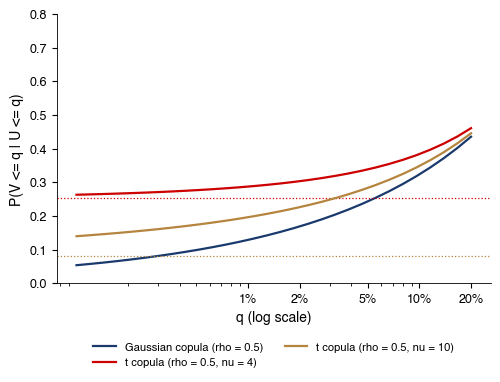

   saved ch6_sem_tail_gauss_t
{'tau': np.float64(0.564189997607083), 'n': 1393, 'rhoS': np.float64(0.7462435107384175), 'pearson': np.float64(0.7808002980939126), 'gaussian': np.float64(0.7746918147138666), 'gaussian_lam': (0.0, 0.0), 'clayton': np.float64(2.5891557995881946), 'clayton_lam': (np.float64(0.7651283713024052), 0.0), 'gumbel': np.float64(2.2945778997940973), 'gumbel_lam': (0.0, np.float64(0.6473299223325486)), 'frank': 7.044166392003187, 'frank_lam': (0.0, 0.0), 'gauss_rhoS': np.float64(0.7596484828943028)}
{'delta': 3.0, 'adj': np.float64(0.3511234415883917), 'infl': np.float64(0.6575959492214292)}


{'lr': np.float64(533.4292714788685), 'r0': np.float64(-0.343480170204782), 'r1': np.float64(0.12553114991036735), 'zt': np.float64(14.92405845420463)}


{'family': 'gaussian', 'par': [0.7707785800505685], 'loglik': 623.3069873766287, 'aic': -1244.6139747532575, 'bic': -1239.3747597794777, 'tau_model': 0.5602650692201933, 'lamL': 0.0, 'lamU': 0.0} {'family': 't', 'par': [0.7750279084815949, 3.9056474800351237], 'loglik': 674.2149814678905, 'aic': -1344.429962935781, 'bic': -1333.9515329882215, 'tau_model': 0.5645284769054757, 'lamL': 0.46677193837314634, 'lamU': 0.46677193837314634} {'stat': 0.1789598193688562, 'p': 0.002, 'B': 499} {'stat': 0.021995198074364453, 'p': 0.874, 'B': 499} 0.002


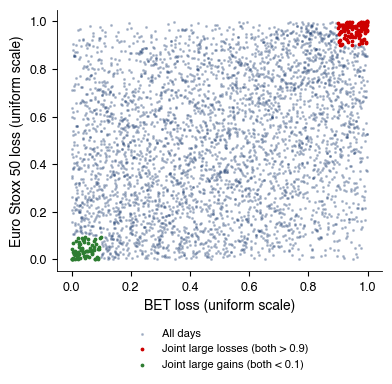

   saved ch6_sem_losses_copula
{'clayton': (-268.96355816959704, 0.004975124378109453), 'gumbel': (-533.2940428126747, 0.22885572139303484), 'gaussian': (-480.22832154528663, 0.004975124378109453), 't': (-501.13341290752226, 0.009900990099009901)}


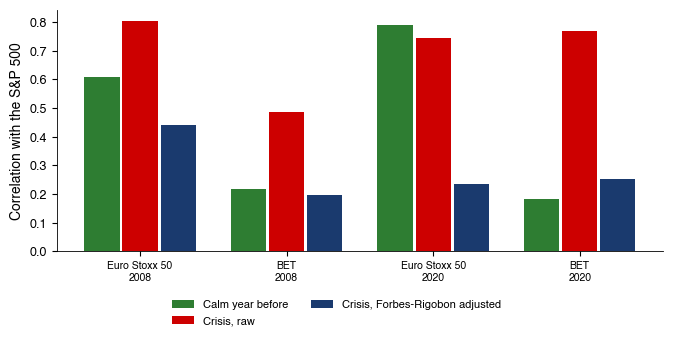

   saved ch6_sem_forbes_rigobon
        rho_calm  rho_crisis  delta  rho_adj  z_raw  p_raw  z_adj  p_adj  \
target                                                                     
stoxx      0.610       0.804  6.544    0.442  2.564  0.005 -1.491  0.932   
bet        0.216       0.485  6.544    0.198  1.975  0.024 -0.122  0.548   

        n_calm  n_crisis  
target                    
stoxx      242       130  
bet        242       130           rho_calm  rho_crisis   delta  rho_adj  z_raw  p_raw  z_adj  p_adj  \
target                                                                      
stoxx      0.790       0.745  20.303    0.235 -0.451  0.674 -3.435   1.00   
bet        0.182       0.769  20.303    0.252  3.447  0.000  0.304   0.38   

        n_calm  n_crisis  
target                    
stoxx      241        47  
bet        241        47  


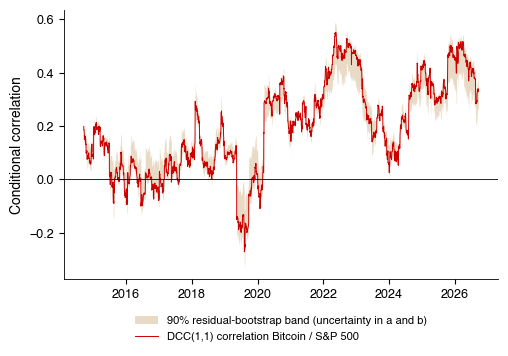

   saved ch6_sem_btc_bands


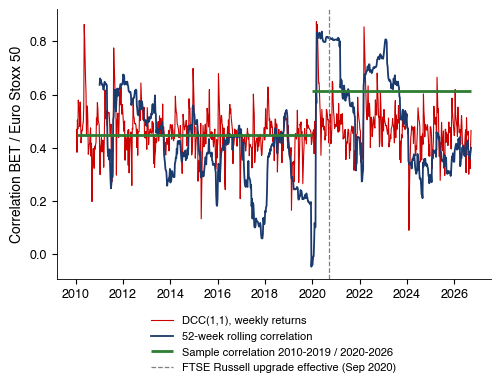

   saved ch6_sem_integration
{'n_pre': 520, 'n_post': 351, 'r_pre': np.float64(0.4484382867121426), 'r_post': np.float64(0.6151889759563578), 'r_post_x': np.float64(0.4985161822190807), 'diff': np.float64(0.1667506892442152), 'ci': array([-0.05031008,  0.33974594]), 'p_boot': np.float64(0.0715), 'delta': 0.21874888547455185, 'adj': np.float64(0.5772004929783102), 'tau_pre': np.float64(0.2597895360901141), 'tau_post': np.float64(0.3174114774114774), 'lamL_pre': np.float64(0.46153846153846156), 'lamL_post': np.float64(0.42735042735042733), 'dcc_a': np.float64(0.09133169064187052), 'dcc_b': np.float64(0.5436766783137309), 'dcc_pre': np.float64(0.4545828308500419), 'dcc_post': np.float64(0.4749233752025838), 'beta_pre': np.float64(0.41916241762156164), 'beta_post': np.float64(0.5402362282276523), 'rd_pre': np.float64(0.38509529080458477), 'rd_post': np.float64(0.5054705745134745)}
{'man_b1_n': 6073, 'man_b1_start': '2002-07-31', 'man_b1_end': '2026-09-18', 'man_b1_date0': '2002-07-31', 'ma

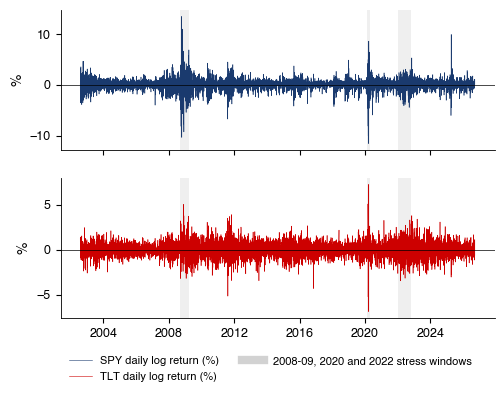

   saved ch6_sem_b1_returns


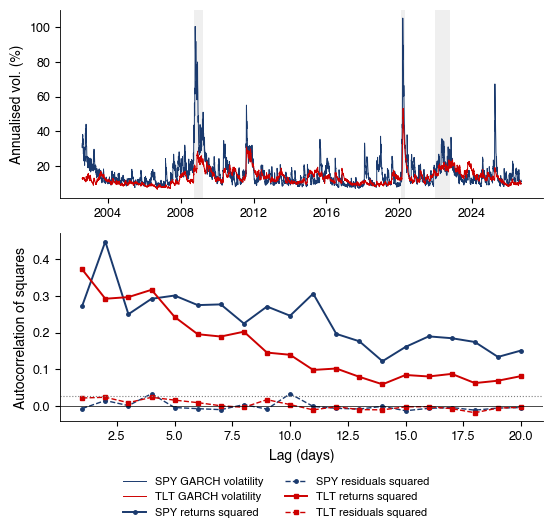

   saved ch6_sem_b1_garch


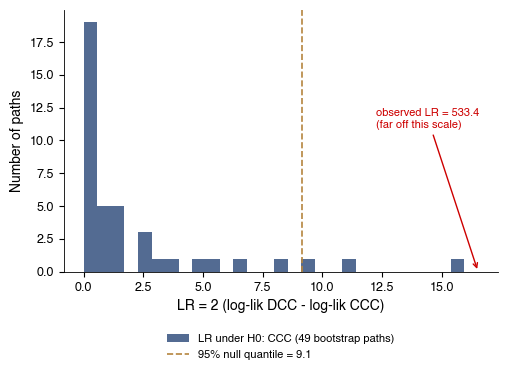

   saved ch6_sem_b1_lr


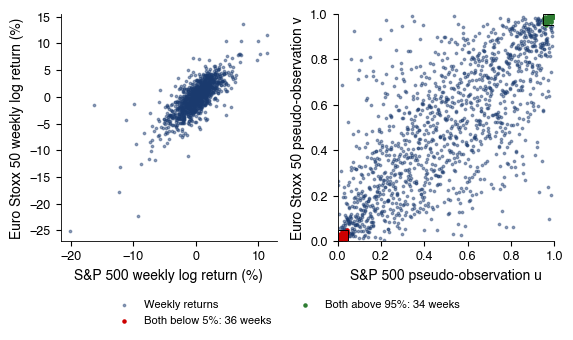

   saved ch6_sem_b2_scatter


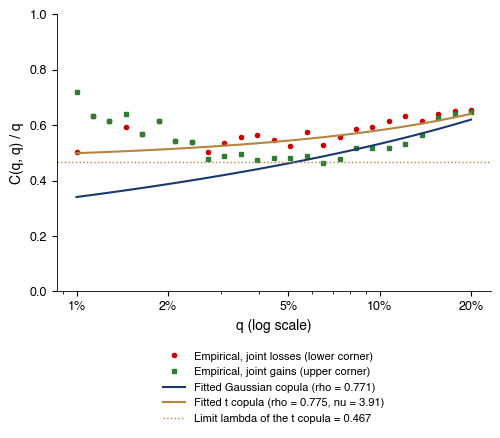

   saved ch6_sem_b2_tails


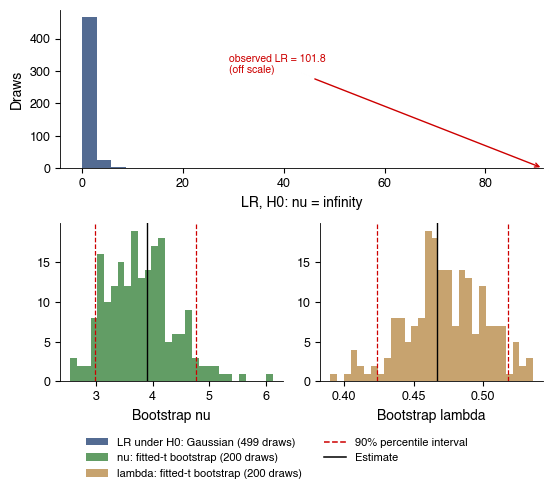

   saved ch6_sem_b2_boot


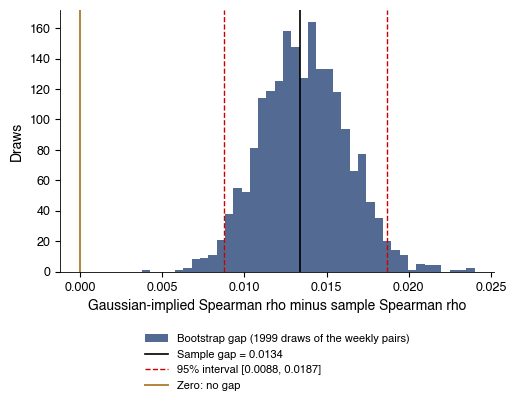

   saved ch6_sem_a2_gap


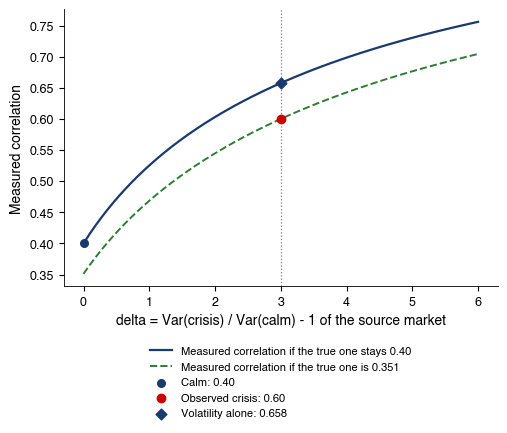

   saved ch6_sem_a3_curve


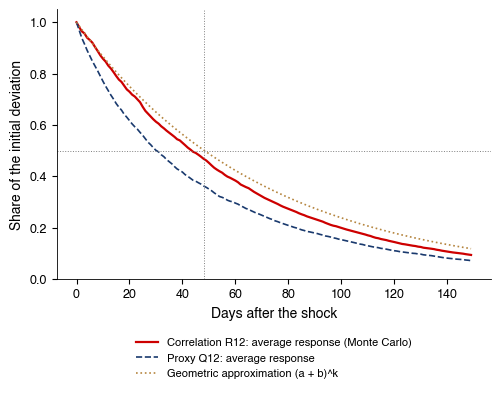

   saved ch6_sem_a5_dcc


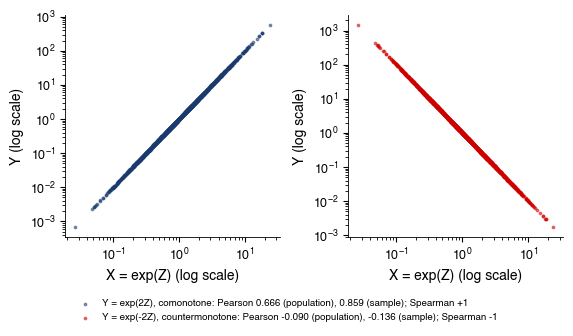

   saved ch6_sem_a6_lognormal


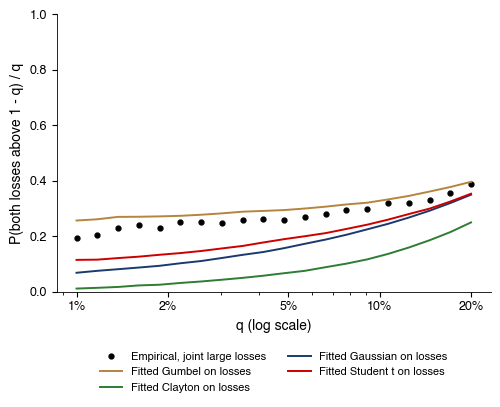

   saved ch6_sem_b3_tails


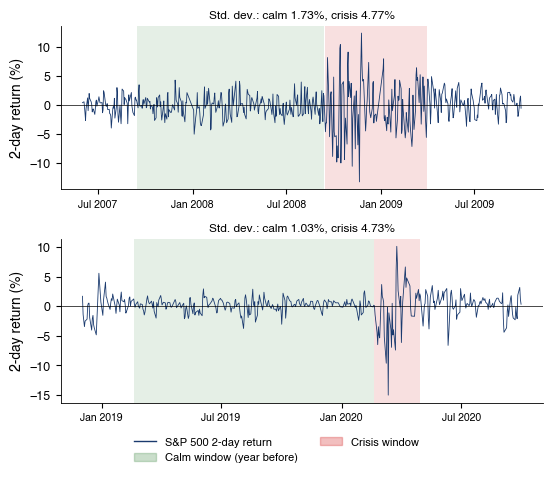

   saved ch6_sem_b4_windows


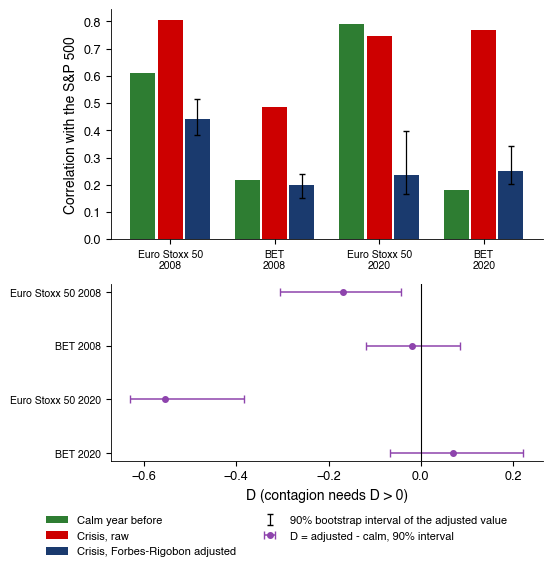

   saved ch6_sem_forbes_rigobon
(np.float64(0.2671176677452237), array([0.16832206, 0.28861841]))


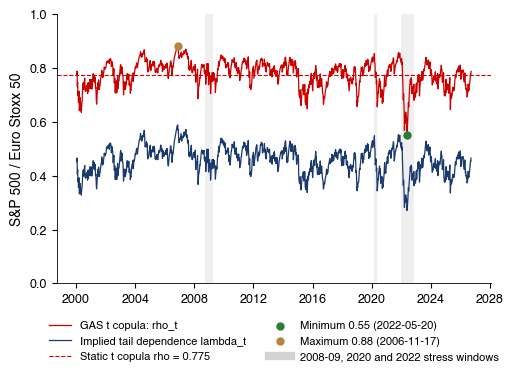

   saved ch6_sem_b6_gas


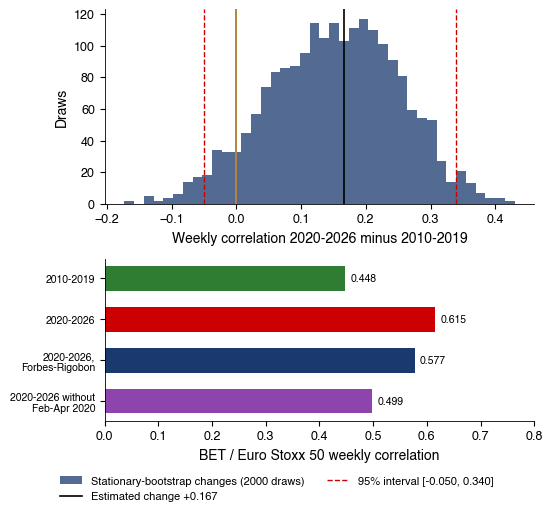

   saved ch6_sem_c1_change


In [8]:
print(a_tail_gauss_t())
fig_tail_gauss_t()
a2, W2, U2 = a_tau_to_theta()
print(a2)
print(a_forbes_rigobon_example())
b1 = b_dcc_spy_tlt()
print({k: b1[k] for k in ('lr', 'r0', 'r1', 'zt')})
b2 = b_gauss_vs_t(W2, U2)
print(b2['fg'], b2['ft'], b2['gg'], b2['gt'], b2['lr_p_boot'])
b3 = b_losses_copula()
fig_losses_copula(b3['U'], b3['res'])
print({f: (r['fit']['aic'], r['gof']['p']) for f, r in b3['res'].items()})
t08, t20, t20b, t08b = b_forbes_rigobon()
fig_forbes_rigobon_sem(t08, t20)
print(t08.round(3), t20.round(3))
b5 = b_btc_bands()
fig_btc_bands(b5)
c = c_integration()
fig_integration_c(c)
print({k: v for k, v in c.items() if k not in ('rc', 'W', 'diffs')})
# new charts of the restructured seminar (fewer bootstrap draws here for speed)
print(s_manifest())
R1 = joint_returns(['spy', 'tlt'])
fig_b1_returns(R1)
P1, V1, Z1, d1, chk = b1_filter_check(R1)
fig_b1_garch(R1, V1, Z1)
lr_obs, lrs = b1_ccc_null_lr(R1, B=49)
fig_b1_lr(lr_obs, lrs)
fig_b2_scatter(W2, U2)
fig_b2_tails(U2, b2['fg'], b2['ft'])
fig_b2_boot(b2['lr'], b2['lr_b'], b2['nu_b'], b2['lam_b'], b2['ft']['par'][1], b2['ft']['lamL'])
gap, gap_b = a2_gap_draws()
fig_a2_gap(gap, gap_b)
fig_a3_curve()
a5 = a5_dcc_numbers(d1['a'], d1['b'], d1['Qbar'][0, 1], M=500)
fig_a5_dcc(a5)
fig_a6_lognormal()
fig_b3_tails(b3['U'], b3['res'])
fig_b4_windows()
fr_d = b4_fr_draws(B=499)
fig_forbes_rigobon_sem(t08, t20, fr_d)
print(b5_mean_change(b5))
g6, rho6 = b6_gas_path()
fig_b6_gas(g6, rho6)
fig_c1_change(c)

![ch6_sem_tail_gauss_t](./ch6_sem_tail_gauss_t.png)

Output: `ch6_sem_tail_gauss_t.pdf`

![ch6_sem_losses_copula](./ch6_sem_losses_copula.png)

Output: `ch6_sem_losses_copula.pdf`

![ch6_sem_forbes_rigobon](./ch6_sem_forbes_rigobon.png)

Output: `ch6_sem_forbes_rigobon.pdf`

![ch6_sem_btc_bands](./ch6_sem_btc_bands.png)

Output: `ch6_sem_btc_bands.pdf`

![ch6_sem_integration](./ch6_sem_integration.png)

Output: `ch6_sem_integration.pdf`

![ch6_sem_b1_returns](./ch6_sem_b1_returns.png)

Output: `ch6_sem_b1_returns.pdf`

![ch6_sem_b1_garch](./ch6_sem_b1_garch.png)

Output: `ch6_sem_b1_garch.pdf`

![ch6_sem_b1_lr](./ch6_sem_b1_lr.png)

Output: `ch6_sem_b1_lr.pdf`

![ch6_sem_b2_scatter](./ch6_sem_b2_scatter.png)

Output: `ch6_sem_b2_scatter.pdf`

![ch6_sem_b2_tails](./ch6_sem_b2_tails.png)

Output: `ch6_sem_b2_tails.pdf`

![ch6_sem_b2_boot](./ch6_sem_b2_boot.png)

Output: `ch6_sem_b2_boot.pdf`

![ch6_sem_a2_gap](./ch6_sem_a2_gap.png)

Output: `ch6_sem_a2_gap.pdf`

![ch6_sem_a3_curve](./ch6_sem_a3_curve.png)

Output: `ch6_sem_a3_curve.pdf`

![ch6_sem_a3_se](./ch6_sem_a3_se.png)

Output: `ch6_sem_a3_se.pdf`

![ch6_sem_a5_dcc](./ch6_sem_a5_dcc.png)

Output: `ch6_sem_a5_dcc.pdf`

![ch6_sem_a6_lognormal](./ch6_sem_a6_lognormal.png)

Output: `ch6_sem_a6_lognormal.pdf`

![ch6_sem_b3_tails](./ch6_sem_b3_tails.png)

Output: `ch6_sem_b3_tails.pdf`

![ch6_sem_b4_windows](./ch6_sem_b4_windows.png)

Output: `ch6_sem_b4_windows.pdf`

![ch6_sem_b6_gas](./ch6_sem_b6_gas.png)

Output: `ch6_sem_b6_gas.pdf`

![ch6_sem_c1_change](./ch6_sem_c1_change.png)

Output: `ch6_sem_c1_change.pdf`